# Pràctica 4: Similitud Lèxica i Semàntica

**Processament del Llenguatge Humà — Grau en Intel·ligència Artificial**

Aquest notebook constitueix alhora el codi i l'informe de la pràctica. L'objectiu és **entrenar i avaluar models d'embeddings distribucionals i contextuals** per a tasques de similitud en espanyol, seguint les tres parts de l'enunciat:

- **Part 1 — Entrenament d'embeddings estàtics.** Word2Vec i fastText entrenats sobre el corpus de la Viquipèdia en espanyol (`raw.es`), comparant l'efecte de la dimensionalitat (25, 50, 100) i de la mida del corpus.
- **Part 2 — Avaluació intrínseca (Multi-SimLex).** Similitud cosinus entre parells de paraules, comparada amb el judici humà mitjançant la correlació de Spearman.
- **Part 3 — Avaluació extrínseca (Spanish STS).** Similitud semàntica entre parells de frases, mesurada amb la correlació de Pearson, amb quatre famílies de models de complexitat creixent: baseline cosinus (mitjana simple i TF-IDF), model seqüencial siamès (BiLSTM + atenció) i model contextual BERT (BETO).

> **Nota sobre el dataset STS.** L'enunciat proposava `PlanTL-GOB-ES/sts-es`. Aquell *loading script* ja no és accessible des de la versió actual de la llibreria `datasets`, de manera que s'ha substituït pel conjunt equivalent `mteb/sts17-crosslingual-sts` (parella `es-es`), que prové de la mateixa font (SemEval-2017, STS cross-lingual). Aquest conjunt és **considerablement més petit** (≈250 parells) que el `sts-es` original, fet que condiciona directament els resultats de la Part 3 i que es discuteix a l'apartat d'anàlisi final.

## Estructura del notebook

**Part 1 — Embeddings estàtics:** entorn i imports · configuració global · preprocessament del corpus · càrrega de Multi-SimLex · grid search de `window`/`sg` · entrenament dels models finals · càrrega del fastText oficial · resum dels models · funcions d'accés als embeddings.

**Part 2 — Avaluació intrínseca:** funció d'avaluació · avaluació de tots els models · anàlisi OOV · taula i gràfics.

**Part 3 — Avaluació extrínseca:** càrrega de Spanish STS · baseline cosinus · vocabulari i tokenització · model siamès BiLSTM · model BERT siamès (BETO) · taula resum, gràfics i anàlisi.


In [3]:
# ── Verificació de l'entorn: comprova que tot el necessari està disponible ──
# Tots els recursos pesats (corpus wiki, fastText oficial, Multi-SimLex) es
# descarreguen manualment una sola vegada i es deixen a les rutes indicades.
# Aquesta cel·la només comprova que hi siguin; no descarrega res.
import sys
from pathlib import Path

print("=" * 60)
print("VERIFICACIÓ DE L'ENTORN")
print("=" * 60)

checks = []

# 1. Corpus wiki
corpus_dir = Path("data/raw.es")
corpus_files = [f for f in corpus_dir.rglob("*") if f.is_file()] if corpus_dir.exists() else []
ok = len(corpus_files) > 0
checks.append(("Corpus wiki (data/raw.es/)", ok,
               f"{len(corpus_files)} fitxers trobats" if ok else
               "NO TROBAT → descarrega raw.es.tgz i descomprimeix-lo a data/raw.es/"))

# 2. Paquets Python essencials
for pkg, import_name in [("gensim","gensim"), ("numpy","numpy"),
                          ("pandas","pandas"), ("sklearn","sklearn"),
                          ("torch","torch"), ("tqdm","tqdm"),
                          ("datasets","datasets"), ("transformers","transformers"),
                          ("scipy","scipy"), ("matplotlib","matplotlib")]:
    try:
        __import__(import_name)
        checks.append((f"pip: {pkg}", True, "instal·lat"))
    except ImportError:
        checks.append((f"pip: {pkg}", False, f"NO → pip install {pkg}"))

# 3. fastText oficial (referència externa de la Part 2)
ft_bin = Path("models/cc.es.300.bin")
if ft_bin.exists():
    checks.append(("fastText oficial (.bin)", True, f"{ft_bin.stat().st_size/1e9:.1f} GB"))
else:
    checks.append(("fastText oficial (.bin)", None,
                   "NO TROBAT (referència externa; veure secció 7)"))

# 4. Multi-SimLex
simlex = Path("data/SPA.tsv")
if simlex.exists():
    checks.append(("Multi-SimLex (data/SPA.tsv)", True, "trobat"))
else:
    checks.append(("Multi-SimLex (data/SPA.tsv)", False,
                   "NO TROBAT → descarrega SPA.tsv a data/"))

# Imprimeix
print()
for name, status, msg in checks:
    icon = "✅" if status is True else ("❌" if status is False else "⚠️ ")
    print(f"  {icon}  {name:<40s}  {msg}")

print()
errors = [c for c in checks if c[1] is False]
if errors:
    print(f"[!] {len(errors)} problema(es) crític(s). Revisa les rutes de descàrrega.")
else:
    print("[OK] Entorn llest per executar la pràctica.")


VERIFICACIÓ DE L'ENTORN

  ✅  Corpus wiki (data/raw.es/)                57 fitxers trobats
  ✅  pip: gensim                               instal·lat
  ✅  pip: numpy                                instal·lat
  ✅  pip: pandas                               instal·lat
  ✅  pip: sklearn                              instal·lat
  ✅  pip: torch                                instal·lat
  ✅  pip: tqdm                                 instal·lat
  ✅  pip: datasets                             instal·lat
  ✅  pip: transformers                         instal·lat
  ✅  pip: scipy                                instal·lat
  ✅  pip: matplotlib                           instal·lat
  ✅  fastText oficial (.bin)                   7.2 GB
  ✅  Multi-SimLex (data/SPA.tsv)               trobat

[OK] Entorn llest per executar la pràctica.


---
## 1. Instal·lació i imports

In [2]:
import os
import re
import json
import logging
import pickle
from pathlib import Path
from typing import List, Dict, Optional, Iterator, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from tqdm.auto import tqdm

# Gensim: Word2Vec i fastText
from gensim.models import Word2Vec, FastText as GensimFastText
from gensim.models.callbacks import CallbackAny2Vec

logging.basicConfig(format='%(asctime)s : %(levelname)s : %(message)s', level=logging.WARNING)
logger = logging.getLogger(__name__)
print("Imports OK")


Imports OK


c:\Natalia\Trabajo\Estudios\5_Inteligencia_Artificial\Q4\PLH\Practica-4-PLH\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---
## 2. Configuració global

Totes les rutes i hiperparàmetres de la pràctica estan centralitzats al diccionari `CONFIG`. Com que tota la feina viu en un únic notebook, les parts 2 i 3 hi accedeixen directament com a variable global, sense cap mecanisme d'importació entre fitxers.


In [5]:
# ══════════════════════════════════════════════════════════════
#  CONFIGURACIÓ GLOBAL  (llegida per les Parts 2 i 3)
# ══════════════════════════════════════════════════════════════

CONFIG = {
    # Rutes
    "corpus_dir"        : "data/raw.es/",
    "source_encoding"   : "cp1252",
    "processed_corpus"  : "data/corpus_processed.txt",
    "models_dir"        : "models/",

    # Preprocessament
    "max_sentences"     : None,   # None = corpus complet
    "min_token_length"  : 2,

    # Hiperparàmetres fixos (no depenen del grid search)
    "min_count"         : 5,
    "workers"           : 8,
    "epochs"            : 5,

    # Dimensions finals a comparar (s'afegirà dim_corpus automàticament)
    "embedding_dims"    : [25, 50, 100],

    # fastText oficial
    "fasttext_official_path" : "models/cc.es.300.bin",
    "fasttext_official_dim"  : 300,

    # Seed de reproducibilitat
    "seed"              : 42,

    # Hiperparàmetres òptims — es populen automàticament després del grid search
    # No els toquis a mà: el grid search els escriurà aquí.
    "best_window" : None,
    "best_sg"     : None,
}

for d in ["data", CONFIG["models_dir"]]:
    Path(d).mkdir(parents=True, exist_ok=True)

print("Configuració inicial carregada.")
print("  [INFO] best_window i best_sg seran populats pel grid search (secció 5).")


Configuració inicial carregada.
  [INFO] best_window i best_sg seran populats pel grid search (secció 5).


In [6]:
# Inspecció del corpus
corpus_dir   = Path(CONFIG["corpus_dir"])
corpus_files = sorted(corpus_dir.rglob("*")) if corpus_dir.exists() else []
corpus_files = [f for f in corpus_files if f.is_file()]


print(f"Fitxers al corpus: {len(corpus_files)}")
total_mb = sum(f.stat().st_size for f in corpus_files) / 1e6
print(f"Mida total: {total_mb:.0f} MB")
for f in corpus_files[:5]:
    print(f"  {f.name}  ({f.stat().st_size/1e6:.1f} MB)")
if len(corpus_files) > 5:
    print(f"  ... i {len(corpus_files)-5} fitxers més")
print()
# Mostra les primeres línies
with open(corpus_files[0], encoding=CONFIG["source_encoding"], errors="replace") as fh:
    for i_line, line in enumerate(fh):
        if line.strip():
            print(line.rstrip()[:120])
        if i_line >= 6:
            break


Fitxers al corpus: 57
Mida total: 678 MB
  spanishText_10000_15000  (20.3 MB)
  spanishText_110000_115000  (14.6 MB)
  spanishText_120000_125000  (14.5 MB)
  spanishText_15000_20000  (26.5 MB)
  spanishText_180000_185000  (11.5 MB)
  ... i 52 fitxers més

<doc id="20540" title="658" nonfiltered="1" processed="1" dbindex="10000">
 Acontecimientos .
 Nacimientos .


---
## 3. Preprocessament del corpus

Genera `corpus_processed.txt`: un fitxer amb una frase per línia i paraules en minúscules separades per espais.


In [7]:
_RE_CLEAN = re.compile(r"[^a-záéíóúüñ'\-]")
_RE_SPACES = re.compile(r"\s+")
_RE_SENT_SPLIT = re.compile(r"(?<=[.!?])\s+")


def preprocess_fragment(fragment: str) -> Optional[List[str]]:
    fragment = fragment.strip()
    if not fragment:
        return None
    fragment = fragment.lower()
    fragment = _RE_CLEAN.sub(" ", fragment)
    fragment = _RE_SPACES.sub(" ", fragment).strip()
    tokens = [t for t in fragment.split() if len(t) >= CONFIG["min_token_length"]]
    return tokens if len(tokens) >= 3 else None


def preprocess_line(line: str) -> Optional[List[List[str]]]:
    line = line.strip()
    if not line or line.startswith("<") or line.startswith("="):
        return None
    sentences = []
    for fragment in _RE_SENT_SPLIT.split(line):
        tokens = preprocess_fragment(fragment)
        if tokens:
            sentences.append(tokens)
    return sentences if sentences else None


def build_processed_corpus(
    corpus_files: List[Path],
    output_path: str,
    max_sentences: Optional[int] = None,
    force_rebuild: bool = False,
) -> int:
    output_file = Path(output_path)
    if output_file.exists() and not force_rebuild:
        n = sum(1 for _ in open(output_file, encoding="utf-8"))
        print(f"El corpus processat ja existeix ({n:,} frases): {output_path}")
        return n
    if output_file.exists():
        output_file.unlink()
    total = 0
    with open(output_file, "w", encoding="utf-8") as out:
        for fpath in tqdm(corpus_files, desc="Fitxers"):
            with open(fpath, encoding=CONFIG["source_encoding"], errors="replace") as fh:
                for line in fh:
                    sentence_list = preprocess_line(line)
                    if sentence_list:
                        for tokens in sentence_list:
                            out.write(" ".join(tokens) + "\n")
                            total += 1
                            if max_sentences and total >= max_sentences:
                                print(f"  [max_sentences={max_sentences} assolit]")
                                return total
    print(f"Corpus processat: {total:,} frases -> {output_path}")
    return total

n_sentences = build_processed_corpus(
    corpus_files,
    CONFIG["processed_corpus"],
    max_sentences=CONFIG["max_sentences"],
    force_rebuild=False,
)
print(f"Total de frases: {n_sentences:,}")


El corpus processat ja existeix (5,461,482 frases): data/corpus_processed.txt
Total de frases: 5,461,482


In [8]:
class SentenceIterator:
    """Iterador perezós sobre corpus_processed.txt."""
    def __init__(self, path: str):
        self.path = path

    def __iter__(self) -> Iterator[List[str]]:
        with open(self.path, encoding="utf-8") as fh:
            for line in fh:
                tokens = line.rstrip().split()
                if tokens:
                    yield tokens

# Verificació ràpida
sentences = SentenceIterator(CONFIG["processed_corpus"])
for i, s in enumerate(sentences):
    print(s)
    if i >= 3:
        break


['fulgencio', 'de', 'écija', 'santo', 'español']
['erquinoaldo', 'mayordomo', 'franco', 'de', 'palacio', 'de', 'neustria']
['egilona', 'última', 'reina', 'visigoda', 'de', 'hispania']
['fin', 'del', 'califato', 'perfecto']


---
## 4. Descàrrega i preparació de Multi-SimLex

Multi-SimLex (Vulic et al., 2020) és un conjunt de dades de similitud semàntica lèxica que conté 1.888 parells de paraules anotats per jutges humans en múltiples idiomes, inclòs l'espanyol (fitxer `SPA.tsv`). Per a cada parell, el conjunt de dades proporciona les puntuacions individuals de fins a 10 anotadors en una escala de 0 a 6, on 0 indica paraules sense cap relació semàntica i 6 indica paraules pràcticament sinònimes.

La **puntuació de similitud oficial** s'obté com la **mitjana aritmètica** de les puntuacions dels anotadors, d'acord amb el protocol estàndard de la publicació original. Això és important perquè el fitxer `SPA.tsv` original no inclou una columna `score` precalculada, sinó les columnes `Annotator 1` a `Annotator 10` de manera individual. La cel·la de càrrega següent s'encarrega d'aquest càlcul.

Aquesta puntuació es fa servir com a mètrica proxy durant el grid search (Secció 5) per seleccionar els hiperparàmetres òptims, i posteriorment com a avaluació intrínseca dels models finals (Secció 7).


In [9]:
# ── Càrrega i preparació de Multi-SimLex ────────────────────────────────────
#
# El fitxer SPA.tsv del Multi-SimLex conté les puntuacions individuals de cada
# anotador (columnes 'Annotator 1' a 'Annotator 10'). La puntuació de similitud
# oficial s'obté com la mitjana aritmètica d'aquests anotadors, seguint el
# protocol estàndard de Multi-SimLex (Vulic et al., 2020).
#
# Referència: https://multisimlex.com
# ─────────────────────────────────────────────────────────────────────────────

SIMLEX_PATH = "data/SPA.tsv"


# ── Càrrega i validació ───────────────────────────────────────────────────────
simlex_df = None

simlex_df = pd.read_csv(SIMLEX_PATH, sep="\t")
print(f"Multi-SimLex carregat: {len(simlex_df)} parells")
print(f"Columnes: {list(simlex_df.columns)}")

# ── Normalització robusta de noms de columnes ─────────────────────────
# Suporta tant el format original (Word 1, Word 2, Annotator X)
# com el format ja processat (word1, word2, score).
col_map = {}
annotator_cols = [c for c in simlex_df.columns if "annotator" in c.lower()]
if annotator_cols and "score" not in simlex_df.columns:
    # Format original: cal calcular la puntuació
    simlex_df["score"] = simlex_df[annotator_cols].mean(axis=1)
    print(f"[INFO] Puntuació calculada com a mitjana de {len(annotator_cols)} anotadors.")
for col in simlex_df.columns:
    cl = col.lower()
    if "word" in cl and "1" in cl: col_map[col] = "word1"
    elif "word" in cl and "2" in cl: col_map[col] = "word2"
simlex_df = simlex_df.rename(columns=col_map)

simlex_df["word1"] = simlex_df["word1"].str.lower().str.strip()
simlex_df["word2"] = simlex_df["word2"].str.lower().str.strip()
simlex_df["score"] = pd.to_numeric(simlex_df["score"], errors="coerce")
simlex_df = simlex_df.dropna(subset=["word1", "word2", "score"])
print(f"Parells vàlids: {len(simlex_df)}")
print(f"Rang de puntuacions: [{simlex_df['score'].min():.2f}, {simlex_df['score'].max():.2f}]")
print(simlex_df[["word1", "word2", "score"]].head(3).to_string(index=False))




Multi-SimLex carregat: 1888 parells
Columnes: ['ID', 'Word 1', 'Word 2', 'PoS', 'Annotator 1', 'Annotator 2', 'Annotator 3', 'Annotator 4', 'Annotator 5', 'Annotator 6', 'Annotator 7', 'Annotator 8', 'Annotator 9', 'Annotator 10']
[INFO] Puntuació calculada com a mitjana de 10 anotadors.
Parells vàlids: 1888
Rang de puntuacions: [0.00, 5.90]
     word1     word2  score
     brazo   músculo    1.4
democracia monarquía    1.3
    tejado     techo    4.8


---
## 5. Grid Search d'hiperparàmetres (`window` i `sg`)

### Per què primer el grid search i no entrenar directament?

L'objectiu principal de la pràctica és **comparar l'efecte de la dimensionalitat** dels embeddings (25, 50, 100). Per fer aquesta comparació de manera rigorosa, tots els models han de ser iguals en tot excepte la dimensió: si cada model tingués el seu propi `window` o `sg`, no podríem atribuir les diferències de rendiment a la dimensió, perquè hauríem canviat múltiples variables alhora.

Per tant, el flux correcte és:

```
1. Grid search  →  troba el millor (window, sg) amb dim=100 i corpus reduït
2. Entrenament  →  entrena tots els models finals amb aquell (window, sg) fix, variant només la dim
```

### Per què dim=100 per al grid i no una altra?

Perquè és la dimensió més gran dels models que comparem. Si una configuració de `window`/`sg` funciona bé amb dim=100 (on el model té més capacitat per absorbir el context), és una elecció conservadora i segura per a les dimensions menors. A l'inrevés no seria vàlid: una configuració òptima per a dim=25 pot ser subòptima per a dim=100.

### Per què corpus reduït?

S'utilitza un subcorpus d'1 milió de frases per agilitzar la cerca: el grid entrena 12 models i fer-ho sobre el corpus complet (5,46M frases) multiplicaria el cost per un factor de ~5 sense canviar el rànquing entre configuracions. Les relacions relatives entre `window` i `sg` es mantenen estables independentment de la mida del corpus.

### Per què 5 epochs i no més?

5 epochs és el valor estàndard per a Word2Vec i fastText sobre corpus grans, i la verificació empírica confirma que és suficient. A diferència de les xarxes neuronals profundes, Word2Vec i fastText presenten una corba de convergència molt ràpida: els increments de pèrdua (Δ) decauen dràsticament i el model s'estabilitza en poques iteracions.

Concretament, per al model més gran (W2V, corpus complet, dim=100) s'ha verificat:

```
Época 1: Δ=61,039,828  ← aprenentatge ràpid
Época 2: Δ= 8,894,188  ← ja ralentitza
Época 3: Δ= 3,153,176  ← convergint
Época 4: Δ= 2,953,680  ← quasi convergit
Época 5: Δ= 2,745,664  ← pràcticament estabilitzat
```

El fet que els Δ segueixin decreixent però de manera molt lenta a les epochs 4 i 5 indica que el model ha convergit i que epochs addicionals aportarien un guany marginal a un cost computacional elevat. A més, s'ha verificat que el rànquing entre configuracions (window, sg) al grid search és estable a partir de l'epoch 3, cosa que valida l'elecció de 5 epochs com a criteri de convergència per al grid.

**Nota metodològica:** la loss reportada per Gensim amb `compute_loss=True` és acumulada (no per epoch), per tant sempre creix. El que mesura la convergència és el **Δ entre epochs consecutives**, no el valor absolut.

**Paràmetres explorats** (amb `vector_size=100` fix, corpus d'1M frases):
- `window`: [3, 5, 8]
- `sg`: [0 (CBOW), 1 (Skip-gram)]

Amb 3×2 = **6 combinacions** × 2 arquitectures (W2V + FT) = **12 models de grid**.


In [10]:
# ── Configuració del grid search ──────────────────────────────────────────
GRID_DIM           = 100
GRID_WINDOW_OPTS   = [3, 5, 8]
GRID_SG_OPTS       = [0, 1]
GRID_MAX_SENTENCES = 1_000_000
GRID_EPOCHS        = 5
FORCE_GRID         = False  # True per forçar reentrenament dels models
FORCE_GRID_CORPUS  = False  # True per forçar reconstrucció del corpus del grid

# ── Corpus reduït ─────────────────────────────────────────────────────────
grid_corpus_path = "data/corpus_grid.txt"
if not Path(grid_corpus_path).exists() or FORCE_GRID_CORPUS:
    print("Construint corpus del grid...")
    build_processed_corpus(
        corpus_files,
        grid_corpus_path,
        max_sentences=GRID_MAX_SENTENCES,
        force_rebuild=True,
    )
else:
    n = sum(1 for _ in open(grid_corpus_path, encoding="utf-8"))
    print(f"Corpus del grid ja existeix: {n:,} frases: {grid_corpus_path}")

Corpus del grid ja existeix: 1,000,000 frases: data/corpus_grid.txt


In [11]:
from itertools import product
from scipy.stats import spearmanr
from numpy.linalg import norm as _norm


def cosine_sim(a, b):
    na, nb = _norm(a), _norm(b)
    return float(np.dot(a, b) / (na * nb)) if na > 1e-10 and nb > 1e-10 else 0.0


def load_simlex(path: str) -> pd.DataFrame:
    """
    Carrega Multi-SimLex des de path i retorna un DataFrame amb columnes
    normalitzades (word1, word2, score), independentment de si el fitxer
    és el format original (Annotator 1..10) o el format ja processat (score).
    Retorna None si el fitxer no existeix o no es pot llegir.
    """
    if not Path(path).exists():
        return None
    try:
        df = pd.read_csv(path, sep="\t")

        # Columnes de paraules: suporta "Word 1", "word1", "WORD1", etc.
        w1c = next((c for c in df.columns if c.lower().replace(" ", "") == "word1"), None)
        w2c = next((c for c in df.columns if c.lower().replace(" ", "") == "word2"), None)
        if w1c is None or w2c is None:
            print(f"[ERROR] No s'han trobat columnes word1/word2 a {path}")
            print(f"        Columnes disponibles: {list(df.columns)}")
            return None

        df = df.rename(columns={w1c: "word1", w2c: "word2"})
        df["word1"] = df["word1"].str.lower().str.strip()
        df["word2"] = df["word2"].str.lower().str.strip()

        # Puntuació: columna "score" ja existent, o mitjana dels anotadors
        if "score" in df.columns:
            df["score"] = pd.to_numeric(df["score"], errors="coerce")
        else:
            ann_cols = [c for c in df.columns if "annotator" in c.lower()]
            if not ann_cols:
                print(f"[ERROR] No s'ha trobat cap columna de puntuació a {path}")
                return None
            df["score"] = df[ann_cols].apply(pd.to_numeric, errors="coerce").mean(axis=1)
            print(f"[INFO] Puntuació calculada com a mitjana de {len(ann_cols)} anotadors.")

        df = df[["word1", "word2", "score"]].dropna()
        print(f"Multi-SimLex carregat: {len(df)} parells vàlids. "
              f"Rang: [{df['score'].min():.2f}, {df['score'].max():.2f}]")
        return df

    except Exception as e:
        print(f"[ERROR] No s'ha pogut carregar {path}: {e}")
        return None


def eval_simlex(model_wv, simlex_df: pd.DataFrame):
    """
    Avalua un KeyedVectors sobre un DataFrame de Multi-SimLex ja carregat.
    Retorna (spearman_rho, n_oov). Si no hi ha prou parells retorna (nan, n_oov).
    """
    if simlex_df is None or simlex_df.empty:
        return float("nan"), -1

    preds, golds, oov = [], [], 0
    for _, row in simlex_df.iterrows():
        w1, w2, gold = row["word1"], row["word2"], row["score"]
        try:
            v1 = (model_wv[w1] if w1 in model_wv.key_to_index
                  else model_wv.get_vector(w1, norm=False))
            v2 = (model_wv[w2] if w2 in model_wv.key_to_index
                  else model_wv.get_vector(w2, norm=False))
            preds.append(cosine_sim(v1, v2))
            golds.append(gold)
        except Exception:
            oov += 1

    if len(preds) < 5:
        return float("nan"), oov
    rho, _ = spearmanr(golds, preds)
    return rho, oov


def get_or_train_model(arch, suffix, common_params, corpus_path, models_dir, force=False):
    """
    Carrega el model si existeix i force=False; altrament l'entrena i el guarda.
    arch: "w2v" o "ft". Retorna el model entrenat.
    """
    cls     = Word2Vec if arch == "w2v" else GensimFastText
    mpath   = Path(models_dir) / f"{arch}_{suffix}.model"
    if mpath.exists() and not force:
        return cls.load(str(mpath))
    sents = SentenceIterator(corpus_path)
    kw    = dict(**common_params)
    m     = (Word2Vec(sentences=sents, compute_loss=True, **kw)
             if arch == "w2v" else GensimFastText(sentences=sents, **kw))
    m.save(str(mpath))
    return m

In [12]:
# ── Entrenament ───────────────────────────────────────────────────────────
# Els models ja entrenats es carreguen des de disc (FORCE_GRID=False).
# Posa FORCE_GRID=True NOMÉS si vols reentrenar des de zero.

_simlex_df   = load_simlex(SIMLEX_PATH)
combinations = list(product(GRID_WINDOW_OPTS, GRID_SG_OPTS))
print(f"Grid search: dim={GRID_DIM}, {len(combinations)} combinacions × 2 arq. "
      f"= {len(combinations) * 2} models")
print(f"Corpus: {GRID_MAX_SENTENCES:,} frases, {GRID_EPOCHS} èpoques\n")

grid_results = []
for win, sg_val in tqdm(combinations, desc="Grid"):
    sg_name = "sg" if sg_val else "cbow"
    suffix  = f"grid_d{GRID_DIM}_w{win}_{sg_name}"
    common  = dict(
        vector_size=GRID_DIM, window=win,
        min_count=CONFIG["min_count"], workers=CONFIG["workers"],
        epochs=GRID_EPOCHS, sg=sg_val, seed=CONFIG["seed"],
    )
    for arch in ["w2v", "ft"]:
        m = get_or_train_model(arch, suffix, common,
                               grid_corpus_path, CONFIG["models_dir"],
                               force=FORCE_GRID)
        rho, oov = eval_simlex(m.wv, _simlex_df)
        grid_results.append({"arch": arch.upper(), "window": win,
                              "sg": sg_name, "spearman_rho": rho, "oov": oov})

[INFO] Puntuació calculada com a mitjana de 10 anotadors.
Multi-SimLex carregat: 1888 parells vàlids. Rang: [0.00, 5.90]
Grid search: dim=100, 6 combinacions × 2 arq. = 12 models
Corpus: 1,000,000 frases, 5 èpoques



Grid: 100%|██████████| 6/6 [00:45<00:00,  7.56s/it]


In [13]:
# ── Resultats i selecció ──────────────────────────────────────────────────
grid_df = pd.DataFrame(grid_results).sort_values("spearman_rho", ascending=False)
print("── Resultats Grid Search ──")
print(grid_df.to_string(index=False))

# Millor per arquitectura
for arch in ["W2V", "FT"]:
    best = grid_df[grid_df["arch"] == arch].iloc[0]
    print(f"\nMillor {arch}: window={best['window']}, sg={best['sg']}, "
            f"ρ={best['spearman_rho']:.4f}")

# Configuració global: mitjana entre W2V i FT per a cada (window, sg)
avg_df = (grid_df.groupby(["window", "sg"])["spearman_rho"]
            .mean().reset_index()
            .sort_values("spearman_rho", ascending=False))
best_g = avg_df.iloc[0]
BEST_WINDOW = int(best_g["window"])
BEST_SG     = 1 if best_g["sg"] == "sg" else 0
print(f"\nConfiguració global òptima (mitjana W2V+FT): "
        f"window={BEST_WINDOW}, sg={BEST_SG} "
        f"({'Skip-gram' if BEST_SG else 'CBOW'}), "
        f"ρ_mitjà={best_g['spearman_rho']:.4f}")


── Resultats Grid Search ──
arch  window   sg  spearman_rho  oov
 W2V       8   sg      0.349597  206
  FT       8   sg      0.340507    0
 W2V       5   sg      0.326696  206
  FT       5   sg      0.326394    0
 W2V       3   sg      0.306344  206
  FT       3   sg      0.303714    0
 W2V       8 cbow      0.297512  206
 W2V       5 cbow      0.278964  206
 W2V       3 cbow      0.263529  206
  FT       8 cbow      0.195668    0
  FT       5 cbow      0.181418    0
  FT       3 cbow      0.170574    0

Millor W2V: window=8, sg=sg, ρ=0.3496

Millor FT: window=8, sg=sg, ρ=0.3405

Configuració global òptima (mitjana W2V+FT): window=8, sg=1 (Skip-gram), ρ_mitjà=0.3451


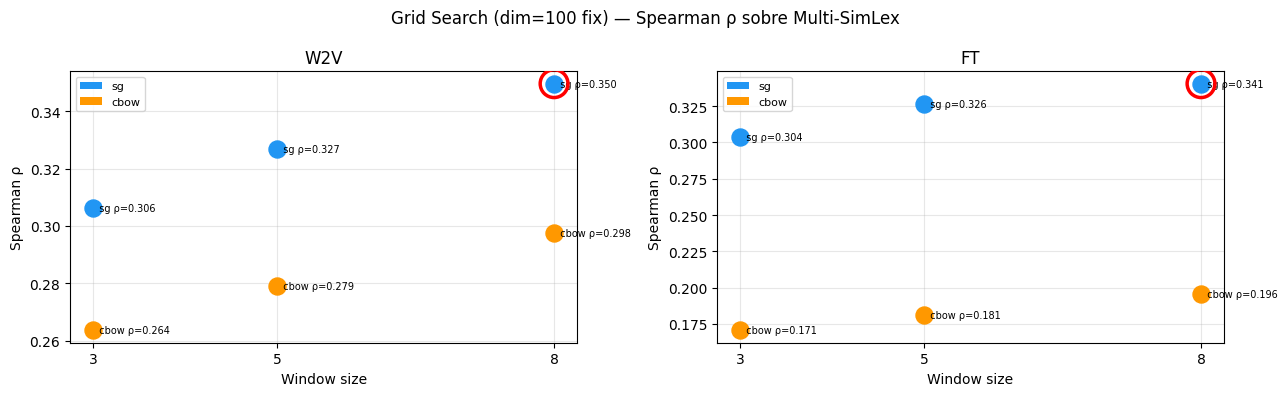

In [14]:


fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle(f"Grid Search (dim={GRID_DIM} fix) — Spearman ρ sobre Multi-SimLex", fontsize=12)
colors = {"sg": "#2196F3", "cbow": "#FF9800"}

for ax, arch in zip(axes, ["W2V", "FT"]):
    sub = grid_df[grid_df["arch"] == arch].copy()
    for _, row in sub.iterrows():
        ax.scatter(row["window"], row["spearman_rho"],
                    color=colors[row["sg"]], s=150, zorder=3)
        ax.annotate(f"  {row['sg']} ρ={row['spearman_rho']:.3f}",
                    (row["window"], row["spearman_rho"]), fontsize=7, va="center")
    # Marca l'òptim global
    opt = sub[(sub["window"]==BEST_WINDOW) & (sub["sg"]==("sg" if BEST_SG else "cbow"))]
    if not opt.empty:
        ax.scatter(opt["window"], opt["spearman_rho"],
                    s=400, facecolors="none", edgecolors="red", linewidths=2.5,
                    zorder=4, label="Òptim global")
    ax.set_title(arch); ax.set_xlabel("Window size"); ax.set_ylabel("Spearman ρ")
    ax.set_xticks(GRID_WINDOW_OPTS); ax.grid(alpha=0.3)
    from matplotlib.patches import Patch
    ax.legend(handles=[Patch(facecolor=c, label=k) for k,c in colors.items()], fontsize=8)

plt.tight_layout(); plt.show()


In [15]:
CONFIG["best_window"] = BEST_WINDOW
CONFIG["best_sg"]     = BEST_SG
print(f"\nCONFIG actualitzat: best_window={BEST_WINDOW}, best_sg={BEST_SG}")


CONFIG actualitzat: best_window=8, best_sg=1


---
## 6. Entrenament dels models finals

Ara que coneixem la millor configuració de `window` i `sg`, entrenem els models finals. Comparem dues coses independents:

### 6a. Efecte de la dimensionalitat (dim=25, 50, 100)
Entrenem W2V i FT amb les tres dimensions sobre el **corpus complet**, mantenint tot igual excepte `vector_size`. Així la comparació és neta: qualsevol diferència de rendiment s'atribueix exclusivament a la dimensió.

### 6b. Efecte de la mida del corpus

L'enunciat diu *"podeu comparar dimensions d'embeddings (e.g. 25, 50, 100) **o mida del corpus**"*. Això vol dir una cosa diferent i independent: entrenar el **mateix model** (dim=100, mateixos hiperparàmetres) però amb **subsets del corpus de mida creixent** (p.ex. 100k, 500k, corpus complet) per veure com afecta el rendiment.

La intuïció és que amb poc corpus el model no veu suficient context per aprendre representacions bones; a partir d'un cert punt el guany per afegir més dades s'estanca. Traçar aquesta corba és una anàlisi habitual en NLP.

Farem ambdues comparacions i les visualitzarem juntes a la Part 2.


In [16]:
# ── Dimensions a comparar (6a: efecte dimensionalitat) ───────────────────
# S'utilitza el corpus complet per garantir que les diferències observades
# entre dimensions siguin atribuïbles exclusivament a la dimensió i no a
# una manca de dades d'entrenament.
ALL_DIMS = CONFIG["embedding_dims"]   # [25, 50, 100]


# ── Mides de corpus a comparar (6b: efecte mida corpus) ──────────────────
# Calculem el total de frases del corpus complet per definir els
# subconjunts com a percentatges, de manera que l'experiment s'adapta
# automàticament si es canvia el corpus.
CORPUS_SIZE_DIM = 100
n_total = sum(1 for _ in open(CONFIG["processed_corpus"], encoding="utf-8"))
print(f"Total frases corpus complet: {n_total:,}")

CORPUS_PERCENTAGES = [0.10, 0.50, 1.00]  # 10%, 50%, 100%
CORPUS_SIZES = [int(n_total * p) if p < 1.0 else None
                for p in CORPUS_PERCENTAGES]
CORPUS_SIZE_LABELS = {
    size: f"{int(p*100)}%"
    for size, p in zip(CORPUS_SIZES, CORPUS_PERCENTAGES)
}


# ── Els dos experiments comparteixen la configuració òptima del grid ──────
# window i sg es mantenen fixos a tots dos experiments per no introduir
# variables addicionals que dificultin la interpretació dels resultats.
print("Configuració dels experiments:")
print(f"  6a — Dimensions: {ALL_DIMS}  (corpus complet, window={CONFIG['best_window']}, sg={CONFIG['best_sg']})")
print(f"  6b — Mides corpus: {[CORPUS_SIZE_LABELS[s] for s in CORPUS_SIZES]}  "
      f"({[s if s else 'complet' for s in CORPUS_SIZES]} frases)  (dim={CORPUS_SIZE_DIM})")


Total frases corpus complet: 5,461,482
Configuració dels experiments:
  6a — Dimensions: [25, 50, 100]  (corpus complet, window=8, sg=1)
  6b — Mides corpus: ['10%', '50%', '100%']  ([546148, 2730741, 'complet'] frases)  (dim=100)


In [17]:
from gensim.models.callbacks import CallbackAny2Vec
from scipy.stats import spearmanr


# ── Callback de pèrdua per època ─────────────────────────────────────────
class EpochLogger(CallbackAny2Vec):
    """
    Registra la pèrdua acumulada i el delta per època.
    Si simlex_df no és None, avalua també el Spearman de Multi-SimLex
    a cada época (útil per verificar convergència).
    """
    def __init__(self, label: str, simlex_df=None):
        self.label     = label
        self.epoch     = 0
        self._prev     = 0
        self.simlex_df = simlex_df
        self.history   = []  # [(loss, delta, rho)]

    def on_epoch_end(self, model):
        self.epoch += 1
        loss  = model.get_latest_training_loss()
        delta = loss - self._prev
        self._prev = loss

        rho     = float("nan")
        rho_str = ""
        if self.simlex_df is not None:
            rho, _ = eval_simlex(model.wv, self.simlex_df)
            rho_str = f"  ρ={rho:.4f}"

        self.history.append((loss, delta, rho))
        print(f"  [{self.label}] Època {self.epoch}/{CONFIG['epochs']}  "
              f"loss={loss:.0f}  Δ={delta:.0f}{rho_str}")


def _model_name(arch: str, dim: int, corpus_path: str,
                window: int, sg: int, min_count: int) -> str:
    """
    Nom canònic del model que inclou tots els hiperparàmetres rellevants.
    Dos models amb els mateixos paràmetres compartiran el mateix fitxer,
    evitant reentrenaments i duplicats en disc.
    Format: {arch}_w{window}_{sg}_mc{min_count}_d{dim}_{corpus_tag}
    """
    sg_tag     = "sg" if sg else "cbow"
    corpus_tag = Path(corpus_path).stem
    return f"{arch}_w{window}_{sg_tag}_mc{min_count}_d{dim}_{corpus_tag}"


def train_word2vec(dim: int, corpus_path: str,
                   force_retrain: bool = False,
                   eval_epochs: bool = False) -> Word2Vec:
    """
    Entrena o carrega W2V amb nom canònic basat en tots els hiperparàmetres.
    Si eval_epochs=True avalua el Spearman de Multi-SimLex a cada època;
    activar només en un model representatiu per verificar convergència.
    """
    name       = _model_name("w2v", dim, corpus_path,
                             CONFIG["best_window"], CONFIG["best_sg"],
                             CONFIG["min_count"])
    model_path = Path(CONFIG["models_dir"]) / f"{name}.model"

    if model_path.exists() and not force_retrain:
        print(f"[OK] Carregant W2V des de {model_path.name}")
        return Word2Vec.load(str(model_path))

    simlex = _simlex_df if eval_epochs else None
    cb     = EpochLogger(name, simlex_df=simlex)
    print(f"\n── Entrenant W2V {name} ──")
    model = Word2Vec(
        sentences=SentenceIterator(corpus_path),
        vector_size=dim,
        window=CONFIG["best_window"], min_count=CONFIG["min_count"],
        workers=CONFIG["workers"],    epochs=CONFIG["epochs"],
        sg=CONFIG["best_sg"],         seed=CONFIG["seed"],
        compute_loss=True,            callbacks=[cb],
    )
    model.save(str(model_path))
    print(f"[OK] Guardat: {model_path.name}")
    return model


def train_fasttext(dim: int, corpus_path: str,
                   force_retrain: bool = False) -> GensimFastText:
    """
    Entrena o carrega FT (gensim) amb nom canònic basat en tots els hiperparàmetres.
    El model de corpus complet amb dim=100 es reutilitza automàticament
    entre l'experiment 6a i el punt 100% de l'experiment 6b.
    """
    name       = _model_name("ft", dim, corpus_path,
                             CONFIG["best_window"], CONFIG["best_sg"],
                             CONFIG["min_count"])
    model_path = Path(CONFIG["models_dir"]) / f"{name}.model"

    if model_path.exists() and not force_retrain:
        print(f"[OK] Carregant FT des de {model_path.name}")
        return GensimFastText.load(str(model_path))

    print(f"\n── Entrenant FT {name} ──")
    model = GensimFastText(
        sentences=SentenceIterator(corpus_path),
        vector_size=dim,
        window=CONFIG["best_window"], min_count=CONFIG["min_count"],
        workers=CONFIG["workers"],    epochs=CONFIG["epochs"],
        sg=CONFIG["best_sg"],         seed=CONFIG["seed"],
    )
    model.save(str(model_path))
    print(f"[OK] Guardat: {model_path.name}")
    return model


def get_or_build_corpus_subset(max_sentences, label: str) -> str:
    """Construeix (si cal) un subcorpus de mida limitada. Retorna la ruta."""
    if max_sentences is None:
        return CONFIG["processed_corpus"]
    path = f"data/corpus_{label}.txt"
    if not Path(path).exists():
        build_processed_corpus(corpus_files, path,
                               max_sentences=max_sentences,
                               force_rebuild=True)
    return path


In [18]:
FORCE_RETRAIN_A = False  # True per forçar reentrenament

# ── 6a: models per dimensió (corpus complet) ─────────────────────────────
print("\n" + "═"*60)
print("6a — Entrenament per DIMENSIÓ (corpus complet)")
print("═"*60)

W2V_MODELS: Dict[str, Word2Vec]       = {}
FT_MODELS:  Dict[str, GensimFastText] = {}

for dim in ALL_DIMS:
    # eval_epochs=True només per al model més gran (dim=100) per verificar
    # convergència. Si el model amb més paràmetres convergeix en 5 epochs,
    # els models de dimensions menors (25, 50) convergiran encara més ràpid.
    eval_ep = (dim == max(ALL_DIMS))
    W2V_MODELS[f"w2v_{dim}"] = train_word2vec(
        dim, CONFIG["processed_corpus"],
        force_retrain=FORCE_RETRAIN_A, eval_epochs=eval_ep)
    FT_MODELS[f"ft_{dim}"] = train_fasttext(
        dim, CONFIG["processed_corpus"],
        force_retrain=FORCE_RETRAIN_A)

print("\nModels per dimensió:", list(W2V_MODELS.keys()) + list(FT_MODELS.keys()))



════════════════════════════════════════════════════════════
6a — Entrenament per DIMENSIÓ (corpus complet)
════════════════════════════════════════════════════════════
[OK] Carregant W2V des de w2v_w8_sg_mc5_d25_corpus_processed.model
[OK] Carregant FT des de ft_w8_sg_mc5_d25_corpus_processed.model
[OK] Carregant W2V des de w2v_w8_sg_mc5_d50_corpus_processed.model
[OK] Carregant FT des de ft_w8_sg_mc5_d50_corpus_processed.model
[OK] Carregant W2V des de w2v_w8_sg_mc5_d100_corpus_processed.model
[OK] Carregant FT des de ft_w8_sg_mc5_d100_corpus_processed.model

Models per dimensió: ['w2v_25', 'w2v_50', 'w2v_100', 'ft_25', 'ft_50', 'ft_100']


In [19]:
FORCE_RETRAIN_B = False  # True per forçar reentrenament

# ── 6b: models per mida de corpus (dim=100 fixa) ─────────────────────────
print("\n" + "═"*60)
print(f"6b — Entrenament per MIDA DE CORPUS (dim={CORPUS_SIZE_DIM})")
print("═"*60)
print("Nota: el model de corpus complet amb dim=100 es reutilitza de 6a")
print("      si els hiperparàmetres coincideixen (nom canònic idèntic).\n")

W2V_CORPUS: Dict[str, Word2Vec]       = {}
FT_CORPUS:  Dict[str, GensimFastText] = {}

for size, label in CORPUS_SIZE_LABELS.items():
    corpus_path = get_or_build_corpus_subset(size, label)
    W2V_CORPUS[f"w2v_{label}"] = train_word2vec(
        CORPUS_SIZE_DIM, corpus_path, force_retrain=FORCE_RETRAIN_B)
    FT_CORPUS[f"ft_{label}"]   = train_fasttext(
        CORPUS_SIZE_DIM, corpus_path, force_retrain=FORCE_RETRAIN_B)

print("\nModels per mida corpus:", list(W2V_CORPUS.keys()) + list(FT_CORPUS.keys()))



════════════════════════════════════════════════════════════
6b — Entrenament per MIDA DE CORPUS (dim=100)
════════════════════════════════════════════════════════════
Nota: el model de corpus complet amb dim=100 es reutilitza de 6a
      si els hiperparàmetres coincideixen (nom canònic idèntic).

[OK] Carregant W2V des de w2v_w8_sg_mc5_d100_corpus_10%.model
[OK] Carregant FT des de ft_w8_sg_mc5_d100_corpus_10%.model
[OK] Carregant W2V des de w2v_w8_sg_mc5_d100_corpus_50%.model
[OK] Carregant FT des de ft_w8_sg_mc5_d100_corpus_50%.model
[OK] Carregant W2V des de w2v_w8_sg_mc5_d100_corpus_processed.model
[OK] Carregant FT des de ft_w8_sg_mc5_d100_corpus_processed.model

Models per mida corpus: ['w2v_10%', 'w2v_50%', 'w2v_100%', 'ft_10%', 'ft_50%', 'ft_100%']


---
## 7. Càrrega del fastText oficial (Facebook)

El model oficial `cc.es.300.bin` (300 dimensions, entrenat sobre Common Crawl) s'usa com a **referència externa** a la Part 2. Per la seva mida (~7 GB) es descarrega a part i es deixa a `models/cc.es.300.bin`. Si no hi és, `FT_OFFICIAL` valdrà `None` i les parts posteriors ho gestionen sense fallar.

Es carrega amb `gensim.models.fasttext.load_facebook_model`, que llegeix el `.bin` directament i no requereix cap paquet addicional. Es fa servir el `.bin` (i no el `.vec`) perquè conté els n-grames de caràcters interns, necessaris per generar vectors de paraules OOV —el principal avantatge de fastText.

Descàrrega:
```
wget https://dl.fbaipublicfiles.com/fasttext/vectors-crawl/cc.es.300.bin.gz
gunzip cc.es.300.bin.gz   # deixar-lo a models/cc.es.300.bin
```


In [20]:
# ── Càrrega del fastText oficial (Facebook) ───────────────────────────────
# S'utilitza el fitxer .bin (i no el .vec) perquè conté els n-grames de
# caràcters interns del model. Això permet generar vectors per a paraules
# OOV mitjançant composició de subparaules, que és el principal avantatge
# de fastText respecte a Word2Vec. El fitxer .vec és un subconjunt del .bin
# que només conté els vectors del vocabulari vist; no suporta OOV.
#
# Descàrrega (terminal):
#   wget https://dl.fbaipublicfiles.com/fasttext/vectors-crawl/cc.es.300.bin.gz
#   gunzip cc.es.300.bin.gz            (Linux/Mac)
#   python -c "import gzip,shutil; shutil.copyfileobj(gzip.open('cc.es.300.bin.gz','rb'), open('cc.es.300.bin','wb'))"   (Windows)

import gensim

FT_OFFICIAL_PATH = CONFIG["fasttext_official_path"]

FT_OFFICIAL = None
if Path(FT_OFFICIAL_PATH).exists():
    print(f"Carregant fastText oficial: {FT_OFFICIAL_PATH} ...")
    FT_OFFICIAL = gensim.models.fasttext.load_facebook_model(FT_OFFICIAL_PATH)
    print(f"[OK] dim={FT_OFFICIAL.vector_size}  vocab={len(FT_OFFICIAL.wv):,}")
else:
    print(f"[AVÍS] Model oficial no trobat a: {FT_OFFICIAL_PATH}")
    print("       Descàrrega:")
    print("         wget https://dl.fbaipublicfiles.com/fasttext/vectors-crawl/cc.es.300.bin.gz")
    print("         (descomprimir) i deixar-lo a models/cc.es.300.bin")


Carregant fastText oficial: models/cc.es.300.bin ...
[OK] dim=300  vocab=2,000,000


---
## 8. Resum i verificació dels models

In [21]:
def _model_file_size_mb(arch: str, dim: int, corpus_path: str) -> float:
    """
    Mida total en MB de tots els fitxers (shards de gensim inclosos) d'un
    model, reconstruint el nom canònic exacte amb _model_name.
    """
    name = _model_name(arch, dim, corpus_path,
                       CONFIG["best_window"], CONFIG["best_sg"],
                       CONFIG["min_count"])
    base = Path(CONFIG["models_dir"])
    return sum(f.stat().st_size for f in base.glob(f"{name}.model*")
               if f.is_file()) / 1e6


print("=" * 70)
print("MODELS ENTRENATS")
print(f"  Hiperparàmetres fixes: window={CONFIG['best_window']}, "
      f"sg={CONFIG['best_sg']} ({'Skip-gram' if CONFIG['best_sg'] else 'CBOW'})")
print("=" * 70)

all_models_info = []

# ── 6a: models per dimensió (corpus complet) ─────────────────────────────
print("\n── 6a: Models per dimensió (corpus complet) ──")
print(f"{'Clau':<18} {'Tipus':<22} {'Dim':>5} {'Vocab':>12} {'MB':>8}")
print("-" * 67)
for key, model in {**W2V_MODELS, **FT_MODELS}.items():
    dim    = model.vector_size
    vocab  = len(model.wv)
    arch_k = "w2v" if key.startswith("w") else "ft"
    arch   = "Word2Vec" if arch_k == "w2v" else "fastText (gensim)"
    size   = _model_file_size_mb(arch_k, dim, CONFIG["processed_corpus"])
    print(f"{key:<18} {arch:<22} {dim:>5} {vocab:>12,} {size:>7.1f}")
    all_models_info.append((key, arch, dim, vocab, size))

# ── 6b: models per mida de corpus (dim=100) ──────────────────────────────
print("\n── 6b: Models per mida de corpus (dim=100) ──")
print(f"{'Clau':<18} {'Tipus':<22} {'Dim':>5} {'Vocab':>12} {'MB':>8}")
print("-" * 67)
_label_to_path = {}
for size_s, label in CORPUS_SIZE_LABELS.items():
    _label_to_path[label] = (CONFIG["processed_corpus"] if size_s is None
                             else f"data/corpus_{label}.txt")

for key, model in {**W2V_CORPUS, **FT_CORPUS}.items():
    dim    = model.vector_size
    vocab  = len(model.wv)
    arch_k = "w2v" if key.startswith("w") else "ft"
    arch   = "Word2Vec" if arch_k == "w2v" else "fastText (gensim)"
    label  = key.split("_", 1)[1]
    cpath  = _label_to_path.get(label, CONFIG["processed_corpus"])
    size   = _model_file_size_mb(arch_k, dim, cpath)
    print(f"{key:<18} {arch:<22} {dim:>5} {vocab:>12,} {size:>7.1f}")

# ── fastText oficial (referència externa) ────────────────────────────────
if FT_OFFICIAL is not None:
    dim_ = (FT_OFFICIAL.get_dimension() if hasattr(FT_OFFICIAL, "get_dimension")
            else FT_OFFICIAL.vector_size)
    poff = Path(CONFIG["fasttext_official_path"])
    sz   = (poff.stat().st_size if poff.exists()
            else poff.with_suffix(".vec").stat().st_size
            if poff.with_suffix(".vec").exists() else 0) / 1e6
    print("\n── fastText oficial (referència externa) ──")
    print(f"{'ft_official':<18} {'fastText oficial':<22} {dim_:>5} {'—':>12} {sz:>7.1f}")


MODELS ENTRENATS
  Hiperparàmetres fixes: window=8, sg=1 (Skip-gram)

── 6a: Models per dimensió (corpus complet) ──
Clau               Tipus                    Dim        Vocab       MB
-------------------------------------------------------------------
w2v_25             Word2Vec                  25      300,250    69.9
w2v_50             Word2Vec                  50      300,250   130.0
w2v_100            Word2Vec                 100      300,250   250.1
ft_25              fastText (gensim)         25      300,250   269.9
ft_50              fastText (gensim)         50      300,250   530.0
ft_100             fastText (gensim)        100      300,250  1050.1

── 6b: Models per mida de corpus (dim=100) ──
Clau               Tipus                    Dim        Vocab       MB
-------------------------------------------------------------------
w2v_10%            Word2Vec                 100       74,229    61.7
w2v_50%            Word2Vec                 100      197,537   164.5
w2v_100%

  Model              Par   Sim
 w2v_25        rey—reina 0.836
 w2v_25       perro—gato 0.931
 w2v_25 madrid—barcelona 0.933
 w2v_50        rey—reina 0.772
 w2v_50       perro—gato 0.910
 w2v_50 madrid—barcelona 0.904
w2v_100        rey—reina 0.693
w2v_100       perro—gato 0.815
w2v_100 madrid—barcelona 0.788
  ft_25        rey—reina 0.851
  ft_25       perro—gato 0.940
  ft_25 madrid—barcelona 0.933
  ft_50        rey—reina 0.825
  ft_50       perro—gato 0.905
  ft_50 madrid—barcelona 0.906
 ft_100        rey—reina 0.745
 ft_100       perro—gato 0.851
 ft_100 madrid—barcelona 0.803


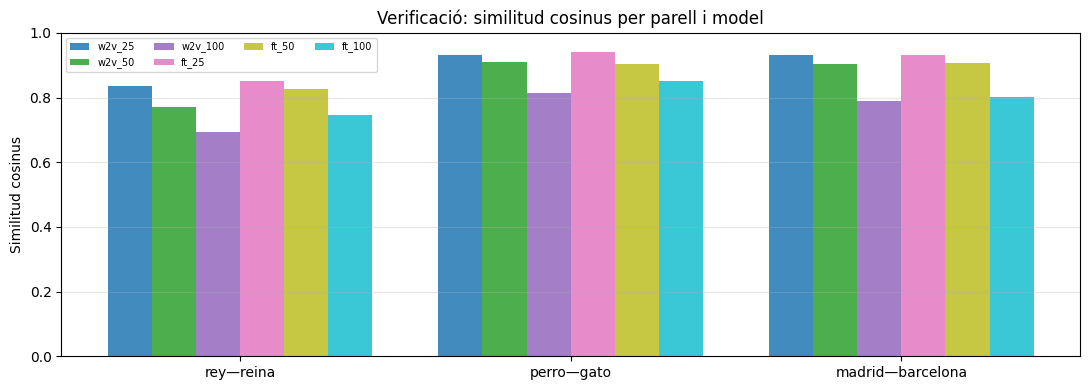

In [22]:
# ── Test de similituds ────────────────────────────────────────────────────
TEST_WORDS = [("rey", "reina"), ("perro", "gato"), ("madrid", "barcelona")]
rows = []
for key, model in {**W2V_MODELS, **FT_MODELS}.items():
    for w1, w2 in TEST_WORDS:
        try:
            sim = model.wv.similarity(w1, w2)
            rows.append({"Model": key, "Par": f"{w1}—{w2}", "Sim": round(sim, 3)})
        except KeyError:
            rows.append({"Model": key, "Par": f"{w1}—{w2}", "Sim": "OOV"})

sim_df = pd.DataFrame(rows)
print(sim_df.to_string(index=False))

plot_df = sim_df[sim_df["Sim"] != "OOV"].copy()
plot_df["Sim"] = plot_df["Sim"].astype(float)
if not plot_df.empty:
    fig, ax = plt.subplots(figsize=(11, 4))
    models_list = list({**W2V_MODELS, **FT_MODELS}.keys())
    x = np.arange(len(TEST_WORDS))
    width = 0.8 / len(models_list)
    colors = plt.cm.tab10(np.linspace(0, 1, len(models_list)))
    for i, (key, color) in enumerate(zip(models_list, colors)):
        vals = []
        for w1, w2 in TEST_WORDS:
            r = plot_df[(plot_df["Model"]==key) & (plot_df["Par"]==f"{w1}—{w2}")]
            vals.append(r["Sim"].values[0] if not r.empty else 0)
        ax.bar(x + i*width - 0.4 + width/2, vals, width, label=key, color=color, alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels([f"{w1}—{w2}" for w1,w2 in TEST_WORDS])
    ax.set_ylabel("Similitud cosinus"); ax.set_ylim(0,1)
    ax.set_title("Verificació: similitud cosinus per parell i model")
    ax.legend(fontsize=7, ncol=4); ax.grid(axis="y", alpha=0.3)
    plt.tight_layout(); plt.show()


---
## 9. Funcions d'accés als embeddings

Aquestes funcions encapsulen l'accés als vectors (de paraula i de frase) i la construcció de la matriu d'embeddings per al model siamès. Com que tota la pràctica viu en un únic notebook, no cal cap mecanisme d'importació entre fitxers: les parts 2 i 3 criden directament aquestes funcions i reutilitzen les variables globals ja definides (`W2V_MODELS`, `FT_MODELS`, `FT_OFFICIAL`, etc.).


In [23]:
def get_word_vector(word: str, model_key: str) -> Optional[np.ndarray]:
    """
    Retorna el vector d'una paraula per a un model determinat.
    model_key: 'w2v_25','w2v_50','w2v_100','ft_25','ft_50','ft_100','ft_official'
    Retorna None si la paraula no es troba (W2V OOV).
    """
    if model_key == "ft_official":
        if FT_OFFICIAL is None:
            return None
        # load_facebook_model retorna un objecte FastText de gensim amb .wv,
        # que genera vectors per a paraules OOV a partir dels n-grames de
        # caràcters (mai falla en retornar un vector).
        return FT_OFFICIAL.wv.get_vector(word, norm=False).astype(np.float32)

    if model_key in W2V_MODELS:
        m = W2V_MODELS[model_key]
        return m.wv[word] if word in m.wv else None

    if model_key in FT_MODELS:
        return FT_MODELS[model_key].wv.get_vector(word, norm=False)

    if model_key in W2V_CORPUS:
        m = W2V_CORPUS[model_key]
        return m.wv[word] if word in m.wv else None

    if model_key in FT_CORPUS:
        return FT_CORPUS[model_key].wv.get_vector(word, norm=False)

    raise ValueError(f"Model desconegut: '{model_key}'. "
                     f"Opcions: {list(W2V_MODELS) + list(FT_MODELS) + list(W2V_CORPUS) + list(FT_CORPUS) + ['ft_official']}")


def get_sentence_vector(
    tokens: List[str],
    model_key: str,
    weights: Optional[np.ndarray] = None,
) -> Optional[np.ndarray]:
    """
    Representa una frase com la mitjana (simple o ponderada amb TF-IDF) dels seus vectors.
    """
    vecs, ws = [], []
    for i, token in enumerate(tokens):
        v = get_word_vector(token, model_key)
        if v is not None:
            vecs.append(v)
            ws.append(weights[i] if weights is not None else 1.0)
    if not vecs:
        return None
    vecs_arr = np.array(vecs)
    ws_arr   = np.array(ws, dtype=np.float32).reshape(-1, 1)
    ws_arr   = ws_arr / (ws_arr.sum() + 1e-9)
    return (vecs_arr * ws_arr).sum(axis=0)


def build_embedding_matrix(
    vocab: Dict[str, int],
    model_key: str,
    dim: int,
) -> np.ndarray:
    """
    Construeix la matriu d'embeddings per al model siamès BiLSTM (Part 3).
    Índex 0 → <PAD>, Índex 1 → <UNK>.
    """
    rng    = np.random.default_rng(CONFIG["seed"])
    matrix = np.zeros((len(vocab), dim), dtype=np.float32)
    matrix[1] = rng.normal(scale=0.01, size=dim)

    n_found, n_oov = 0, 0
    for word, idx in vocab.items():
        if idx <= 1:
            continue
        v = get_word_vector(word, model_key)
        if v is not None:
            matrix[idx] = v
            n_found += 1
        else:
            matrix[idx] = rng.normal(scale=0.01, size=dim)
            n_oov += 1

    coverage = n_found / (n_found + n_oov + 1e-9)
    print(f"[{model_key}] Matriu embeddings: {matrix.shape}  "
          f"cobertura={coverage:.1%}  OOV={n_oov:,}")
    return matrix


def is_oov(word: str, model_key: str) -> bool:
    # OOV = la paraula NO és al vocabulari après pel model.
    # IMPORTANT: per a fastText, ser OOV no vol dir que no es pugui obtenir un
    # vector — fastText sempre en composa un a partir dels n-grames de caràcters.
    # Però per fer una comparació justa amb Word2Vec, aquí mesurem la pertinença
    # al vocabulari (key_to_index), igual per a tots dos tipus de model.
    if model_key in W2V_MODELS:
        return word not in W2V_MODELS[model_key].wv.key_to_index
    if model_key in W2V_CORPUS:
        return word not in W2V_CORPUS[model_key].wv.key_to_index
    if model_key in FT_MODELS:
        return word not in FT_MODELS[model_key].wv.key_to_index
    if model_key in FT_CORPUS:
        return word not in FT_CORPUS[model_key].wv.key_to_index
    if model_key == "ft_official":
        if FT_OFFICIAL is None:
            return True
        return word not in FT_OFFICIAL.wv.key_to_index
    raise ValueError(f"Model desconegut: {model_key}")


# ── Prova ─────────────────────────────────────────────────────────────────
print("Prova get_word_vector:")
v = get_word_vector("gato", "w2v_100")
print(f"  'gato' w2v_100 → {v[:5] if v is not None else 'OOV'}...")

print("\nProva get_sentence_vector:")
sv = get_sentence_vector(["el", "gato", "come"], "ft_100")
print(f"  'el gato come' ft_100 → {sv[:5] if sv is not None else 'Error'}...")

print("\nFuncions d'accés als embeddings llestes.")


Prova get_word_vector:
  'gato' w2v_100 → [ 0.10570432  0.03614071  0.11962759  0.12293452 -0.25332263]...

Prova get_sentence_vector:
  'el gato come' ft_100 → [ 0.13889748  0.17780888  0.3453189  -0.01238065  0.37309027]...

Funcions d'accés als embeddings llestes.


---
### Resum de les funcions i variables compartides

Les parts 2 i 3 reutilitzen directament aquests objectes, ja definits en memòria:

| Variable / Funció | Tipus | Descripció |
|---|---|---|
| `CONFIG` | `dict` | Configuració global de la pràctica |
| `W2V_MODELS` | `dict[str, Word2Vec]` | Models Word2Vec per dimensió: `w2v_25`, `w2v_50`, `w2v_100` |
| `FT_MODELS` | `dict[str, GensimFastText]` | Models fastText (gensim) per dimensió: `ft_25`, `ft_50`, `ft_100` |
| `W2V_CORPUS`, `FT_CORPUS` | `dict` | Models per mida de corpus (`10%`, `50%`, `100%`) |
| `FT_OFFICIAL` | model o `None` | fastText oficial de Facebook (300d) |
| `get_word_vector(word, model_key)` | funció | Vector d'una paraula |
| `get_sentence_vector(tokens, model_key, weights?)` | funció | Vector agregat (mitjana simple o TF-IDF) |
| `build_embedding_matrix(vocab, model_key, dim)` | funció | Matriu d'embeddings per al BiLSTM |
| `is_oov(word, model_key)` | funció | Comprova si una paraula és fora del vocabulari après |


---
---
# Part 2: Avaluació Intrínseca (Multi-SimLex)

**Objectiu**: Avaluar els embeddings sobre parells de paraules usant la correlació de Spearman.

## Índex Part 2
1. [Càrrega de Multi-SimLex](#p2-1-càrrega-de-multi-simlex)
2. [Funció d'avaluació intrínseca](#p2-2-funció-devaluació)
3. [Avaluació de tots els models](#p2-3-avaluació-de-tots-els-models)
4. [Anàlisi OOV](#p2-4-anàlisi-oov)
5. [Taula de resultats i gràfics](#p2-5-taula-i-gràfics)


---
### P2-2. Funció d'avaluació intrínseca

In [24]:
from scipy.stats import spearmanr
from numpy.linalg import norm as np_norm

def cosine_sim_np(a: np.ndarray, b: np.ndarray) -> float:
    na, nb = np_norm(a), np_norm(b)
    if na < 1e-10 or nb < 1e-10:
        return 0.0
    return float(np.dot(a, b) / (na * nb))


def evaluate_intrinsic(
    model_key: str,
    df: pd.DataFrame,
) -> Dict:
    """
    Avalua un model sobre Multi-SimLex.
    Retorna un diccionari amb: model, spearman_rho, n_pairs, n_oov, oov_ratio.
    """
    if df is None or df.empty:
        return {"model": model_key, "spearman_rho": float("nan"),
                "n_pairs": 0, "n_oov": 0, "oov_ratio": float("nan")}

    preds, golds, oov_pairs = [], [], 0
    oov_words = set()

    for _, row in df.iterrows():
        w1, w2, gold = row["word1"], row["word2"], row["score"]
        v1 = get_word_vector(w1, model_key)
        v2 = get_word_vector(w2, model_key)

        if v1 is None or v2 is None:
            oov_pairs += 1
            if v1 is None: oov_words.add(w1)
            if v2 is None: oov_words.add(w2)
            continue

        preds.append(cosine_sim_np(v1, v2))
        golds.append(gold)

    n_total = len(df)
    oov_ratio = oov_pairs / n_total if n_total > 0 else 0

    if len(preds) < 5:
        rho = float("nan")
    else:
        rho, _ = spearmanr(golds, preds)

    return {
        "model"       : model_key,
        "spearman_rho": round(rho, 4) if not np.isnan(rho) else float("nan"),
        "n_pairs"     : len(preds),
        "n_oov"       : oov_pairs,
        "oov_ratio"   : round(oov_ratio, 3),
    }


---
### P2-3. Avaluació de tots els models

In [25]:
# ── Llista de models a avaluar ───────────────────────────────────────────
# Incloem tant els models per dimensió com els de mida de corpus
models_to_eval = list(W2V_MODELS.keys()) + list(FT_MODELS.keys())
models_to_eval += list(W2V_CORPUS.keys()) + list(FT_CORPUS.keys())
if FT_OFFICIAL is not None:
    models_to_eval.append("ft_official")

print(f"Avaluant {len(models_to_eval)} models sobre Multi-SimLex...")

intrinsic_results = []
for key in tqdm(models_to_eval, desc="Avaluació intrínseca"):
    res = evaluate_intrinsic(key, simlex_df)
    intrinsic_results.append(res)
    status = f"ρ={res['spearman_rho']:.4f}" if not np.isnan(res['spearman_rho']) else "N/A"
    print(f"  {key:<22}: {status}  OOV={res['oov_ratio']:.1%}")

intrinsic_df = pd.DataFrame(intrinsic_results).sort_values("spearman_rho", ascending=False)


Avaluant 13 models sobre Multi-SimLex...


Avaluació intrínseca:   8%|▊         | 1/13 [00:00<00:02,  4.50it/s]

  w2v_25                : ρ=0.3503  OOV=6.4%


Avaluació intrínseca:  23%|██▎       | 3/13 [00:00<00:02,  4.70it/s]

  w2v_50                : ρ=0.3737  OOV=6.4%
  w2v_100               : ρ=0.3972  OOV=6.4%


...

  ft_10%                : ρ=0.2963  OOV=0.0%


Avaluació intrínseca:  85%|████████▍ | 11/13 [00:07<00:02,  1.07s/it]

  ft_50%                : ρ=0.3648  OOV=0.0%


Avaluació intrínseca: 100%|██████████| 13/13 [00:07<00:00,  1.63it/s]

  ft_100%               : ρ=0.3836  OOV=0.0%
  ft_official           : ρ=0.5034  OOV=0.0%


---
### P2-4. Anàlisi OOV

In [26]:
# ── Anàlisi detallada de les paraules OOV ────────────────────────────────
if simlex_df is not None:
    all_words = set(simlex_df["word1"].tolist() + simlex_df["word2"].tolist())
    print(f"Vocabulari de Multi-SimLex: {len(all_words)} paraules úniques\n")

    # Diccionari unificat de tots els models per obtenir vocab_size
    _all_models = {**W2V_MODELS, **FT_MODELS, **W2V_CORPUS, **FT_CORPUS}

    oov_table = []
    for key in models_to_eval:
        oov_words = [w for w in all_words if is_oov(w, key)]
        if key in _all_models:
            vocab_size = len(_all_models[key].wv)
        elif key == "ft_official" and FT_OFFICIAL is not None:
            vocab_size = len(FT_OFFICIAL.wv)
        else:
            vocab_size = "—"
        oov_table.append({
            "model"       : key,
            "vocab_size"  : vocab_size,
            "oov_count"   : len(oov_words),
            "oov_pct"     : f"{len(oov_words)/len(all_words):.1%}",
            "oov_examples": ", ".join(oov_words[:5]) if oov_words else "cap",
        })

    oov_df = pd.DataFrame(oov_table)
    print("Anàlisi OOV:")
    print(oov_df.to_string(index=False))
    print()
    print("[INFO] OOV = paraula fora del vocabulari après pel model.")
    print("       fastText TÉ paraules OOV igual que Word2Vec, però a diferència")
    print("       d'aquest pot generar-ne un vector compost amb n-grames de")
    print("       caràcters, de manera que mai falla en retornar un vector.")


Vocabulari de Multi-SimLex: 2062 paraules úniques

Anàlisi OOV:
      model  vocab_size  oov_count oov_pct                                                                     oov_examples
     w2v_25      300250         93    4.5%                un pan, código malicioso, barco de cañón, teléfono inteligente, 0
     w2v_50      300250         93    4.5%                un pan, código malicioso, barco de cañón, teléfono inteligente, 0
    w2v_100      300250         93    4.5%                un pan, código malicioso, barco de cañón, teléfono inteligente, 0
      ft_25      300250         93    4.5%                un pan, código malicioso, barco de cañón, teléfono inteligente, 0
      ft_50      300250         93    4.5%                un pan, código malicioso, barco de cañón, teléfono inteligente, 0
     ft_100      300250         93    4.5%                un pan, código malicioso, barco de cañón, teléfono inteligente, 0
    w2v_10%       74229        223   10.8%                          

---
### P2-5. Taula de resultats i gràfics

AVALUACIÓ INTRÍNSECA — Multi-SimLex (Spearman ρ)
      model  spearman_rho  n_pairs  n_oov  oov_ratio
ft_official        0.5034     1888      0      0.000
   w2v_100%        0.3972     1767    121      0.064
    w2v_100        0.3972     1767    121      0.064
     ft_100        0.3836     1888      0      0.000
    ft_100%        0.3836     1888      0      0.000
    w2v_50%        0.3774     1749    139      0.074
     w2v_50        0.3737     1767    121      0.064
      ft_50        0.3675     1888      0      0.000
     ft_50%        0.3648     1888      0      0.000
     w2v_25        0.3503     1767    121      0.064
      ft_25        0.3484     1888      0      0.000
    w2v_10%        0.3107     1621    267      0.141
     ft_10%        0.2963     1888      0      0.000



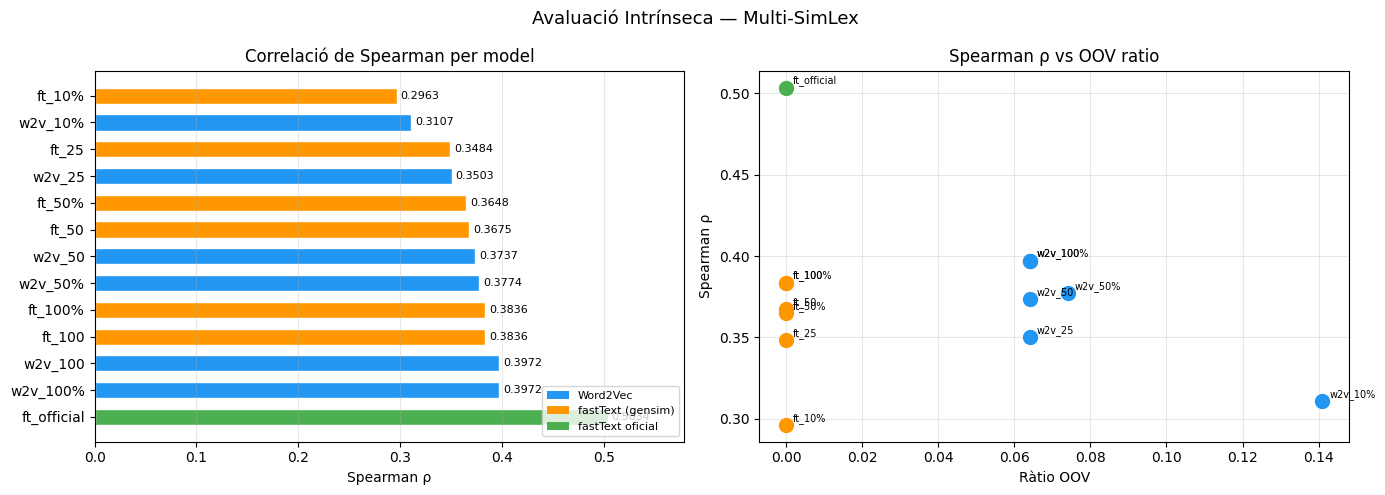

In [27]:
# ── Taula de resultats ────────────────────────────────────────────────────
print("=" * 60)
print("AVALUACIÓ INTRÍNSECA — Multi-SimLex (Spearman ρ)")
print("=" * 60)
print(intrinsic_df.to_string(index=False))
print()

# ── Gràfic barres: Spearman ρ per model ──────────────────────────────────
valid_df = intrinsic_df.dropna(subset=["spearman_rho"])

if not valid_df.empty:
    # Paleta: W2V en blau, FT-gensim en taronja, FT-oficial en verd
    def model_color(name):
        if "official" in name: return "#4CAF50"
        if name.startswith("ft"): return "#FF9800"
        return "#2196F3"

    colors = [model_color(m) for m in valid_df["model"]]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("Avaluació Intrínseca — Multi-SimLex", fontsize=13)

    # Gràfic 1: ρ per model
    ax = axes[0]
    bars = ax.barh(valid_df["model"], valid_df["spearman_rho"],
                   color=colors, edgecolor="white", height=0.6)
    ax.set_xlabel("Spearman ρ")
    ax.set_title("Correlació de Spearman per model")
    ax.set_xlim(0, max(valid_df["spearman_rho"].max() * 1.15, 0.1))
    ax.axvline(0, color="black", lw=0.5)
    ax.bar_label(bars, fmt="%.4f", padding=3, fontsize=8)
    ax.grid(axis="x", alpha=0.3)

    # Llegenda manual
    from matplotlib.patches import Patch
    legend_elems = [
        Patch(facecolor="#2196F3", label="Word2Vec"),
        Patch(facecolor="#FF9800", label="fastText (gensim)"),
        Patch(facecolor="#4CAF50", label="fastText oficial"),
    ]
    ax.legend(handles=legend_elems, loc="lower right", fontsize=8)

    # Gràfic 2: ρ vs OOV ratio
    ax2 = axes[1]
    for _, row in valid_df.iterrows():
        ax2.scatter(row["oov_ratio"], row["spearman_rho"],
                    color=model_color(row["model"]), s=100, zorder=3)
        ax2.annotate(row["model"], (row["oov_ratio"], row["spearman_rho"]),
                     textcoords="offset points", xytext=(5, 3), fontsize=7)
    ax2.set_xlabel("Ràtio OOV")
    ax2.set_ylabel("Spearman ρ")
    ax2.set_title("Spearman ρ vs OOV ratio")
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print("[INFO] No hi ha resultats vàlids per graficar (potser falta Multi-SimLex).")


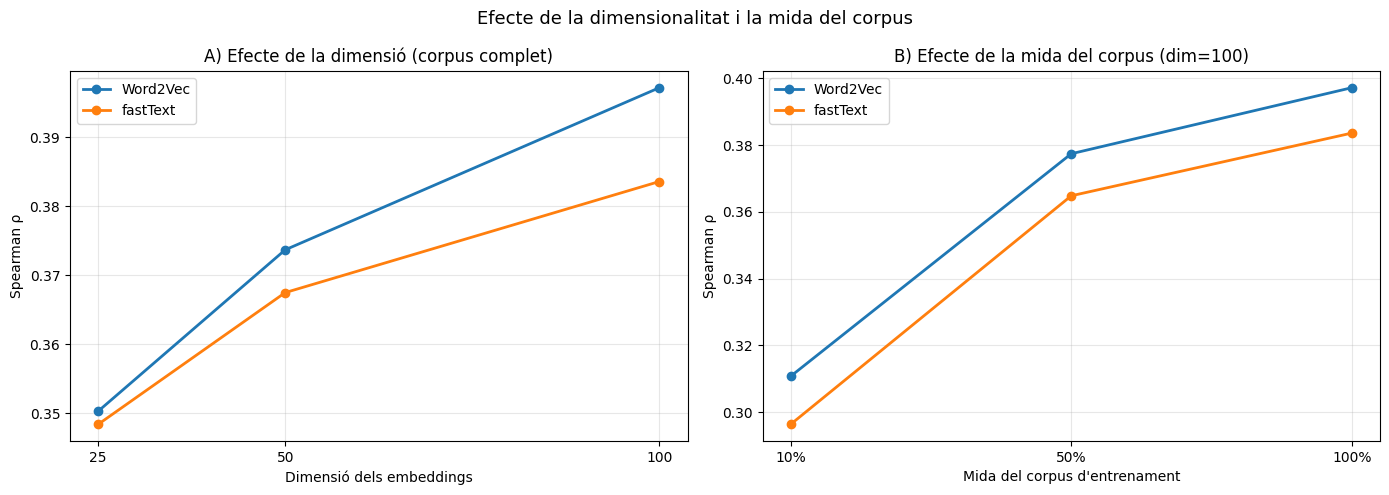

In [28]:
# ── Gràfic A: efecte de la dimensionalitat ───────────────────────────────
dim_df = intrinsic_df[intrinsic_df["model"].isin(
    list(W2V_MODELS.keys()) + list(FT_MODELS.keys())
)].copy()
dim_df["arch"] = dim_df["model"].apply(lambda x: "Word2Vec" if x.startswith("w") else "fastText")
dim_df["dim"]  = dim_df["model"].apply(lambda x: int(x.split("_")[1]))

# ── Gràfic B: efecte de la mida del corpus ───────────────────────────────
# Les etiquetes reals dels models de corpus venen de CORPUS_SIZE_LABELS,
# que són percentatges ("10%", "50%", "100%"), NO "100k"/"500k"/"complet".
# Construïm l'ordre dinàmicament a partir de CORPUS_PERCENTAGES.
ordered_labels = [f"{int(p*100)}%" for p in CORPUS_PERCENTAGES]      # ["10%","50%","100%"]
label_to_x     = {lab: i for i, lab in enumerate(ordered_labels)}    # {"10%":0,...}

corpus_df = intrinsic_df[intrinsic_df["model"].isin(
    list(W2V_CORPUS.keys()) + list(FT_CORPUS.keys())
)].copy()
corpus_df["arch"]  = corpus_df["model"].apply(lambda x: "Word2Vec" if x.startswith("w") else "fastText")
corpus_df["label"] = corpus_df["model"].apply(lambda x: x.split("_", 1)[1])  # "10%","50%","100%"

valid_dim    = dim_df.dropna(subset=["spearman_rho"])
valid_corpus = corpus_df.dropna(subset=["spearman_rho"])

if not valid_dim.empty or not valid_corpus.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("Efecte de la dimensionalitat i la mida del corpus", fontsize=13)

    # Gràfic A
    ax = axes[0]
    if not valid_dim.empty:
        for arch, grp in valid_dim.groupby("arch"):
            grp = grp.sort_values("dim")
            ax.plot(grp["dim"], grp["spearman_rho"], marker="o", label=arch, linewidth=2)
        ax.set_xlabel("Dimensió dels embeddings")
        ax.set_ylabel("Spearman ρ")
        ax.set_title("A) Efecte de la dimensió (corpus complet)")
        ax.set_xticks(ALL_DIMS)
        ax.legend(); ax.grid(alpha=0.3)
    else:
        ax.text(0.5, 0.5, "Sense dades", ha="center", va="center", transform=ax.transAxes)

    # Gràfic B
    ax2 = axes[1]
    if not valid_corpus.empty:
        for arch, grp in valid_corpus.groupby("arch"):
            grp = grp.copy()
            grp["x"] = grp["label"].map(label_to_x)
            grp = grp.dropna(subset=["x"]).sort_values("x")
            ax2.plot(grp["x"], grp["spearman_rho"], marker="o", label=arch, linewidth=2)
        ax2.set_xticks(range(len(ordered_labels)))
        ax2.set_xticklabels(ordered_labels)
        ax2.set_xlabel("Mida del corpus d'entrenament")
        ax2.set_ylabel("Spearman ρ")
        ax2.set_title(f"B) Efecte de la mida del corpus (dim={CORPUS_SIZE_DIM})")
        ax2.legend(); ax2.grid(alpha=0.3)
    else:
        ax2.text(0.5, 0.5, "Sense dades", ha="center", va="center", transform=ax2.transAxes)

    plt.tight_layout()
    plt.show()

---
---
# Part 3: Avaluació Extrínseca (Spanish STS)

**Objectiu:** avaluar models per a la similitud semàntica de frases (STS) en espanyol, mesurada amb la correlació de **Pearson** sobre el conjunt de test.

Comparem quatre famílies de models de complexitat creixent:

1. **Baseline cosinus** — representació de cada frase com a vector agregat (mitjana simple i mitjana ponderada amb TF-IDF) i similitud cosinus entre les dues frases. No requereix entrenament.
2. **Model seqüencial siamès** — Embedding → BiLSTM → atenció → MLP de regressió, amb embeddings estàtics congelats o entrenables.
3. **Model BERT siamès (BETO)** — `bert-base-spanish-wwm-cased` → mean pooling → MLP de regressió.

> **Advertència sobre les dades (clau per interpretar els resultats).** Com s'ha explicat a la introducció, el conjunt `mteb/sts17-crosslingual-sts` (es-es) que substitueix el `PlanTL-GOB-ES/sts-es` original només té ≈250 parells de frases. En dividir-lo 70/15/15 queden unes poques centenes de parells per entrenar i només unes desenes per a dev i test. Aquesta escassetat afecta de manera severa els models que **necessiten entrenament** (BiLSTM i BERT): amb tan poques mostres, les xarxes no poden aprendre una funció de regressió estable i el Pearson de test resulta molt baix —fins i tot negatiu en alguns casos—, mentre que els **baselines cosinus**, que no entrenen res, es mantenen molt més robustos. Aquesta asimetria és el fil conductor de l'anàlisi final.

## Índex Part 3
1. Càrrega del dataset Spanish STS
2. Baseline cosinus
3. Vocabulari i tokenització
4. Model siamès BiLSTM (amb cerca d'hiperparàmetres)
5. Model BERT siamès (BETO)
6. Taula resum, gràfics i anàlisi final


---
### P3-1. Càrrega del dataset Spanish STS

In [29]:
from datasets import load_dataset
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity as sk_cosine

# ── Càrrega del dataset Spanish STS ──────────────────────────────────────
# L'enunciat proposava "PlanTL-GOB-ES/sts-es", però el seu loading script ja
# no és accessible des de la versió actual de la llibreria `datasets`. Usem
# el conjunt equivalent "mteb/sts17-crosslingual-sts" (parella es-es), que
# prové de la mateixa font (SemEval-2017 STS) i té un format estàndard.
#
# IMPLICACIÓ IMPORTANT: aquest conjunt només porta un split "test" d'uns ~250
# parells, molt més petit que el sts-es original. El dividim manualment en
# train/dev/test (70/15/15). Aquesta escassetat de dades és la causa principal
# del baix rendiment dels models entrenats (BiLSTM i BERT), com es discuteix
# a l'anàlisi final.
print("Carregant Spanish STS (SemEval-2017 cross-lingual, parella es-es)...")
ds = load_dataset("mteb/sts17-crosslingual-sts", "es-es")

full_df = ds["test"].to_pandas()
print(f"Columnes: {list(full_df.columns)}")
print(f"Total parells: {len(full_df)}")

# Divisió 70/15/15 (test_size=0.176 del 85% restant ≈ 15% del total)
temp_df, test_df = train_test_split(full_df, test_size=0.15, random_state=42)
train_df, dev_df = train_test_split(temp_df,  test_size=0.176, random_state=42)

# Normalitzem els scores a [0, 1] (l'escala original de STS és 0–5)
for _df in [train_df, dev_df, test_df]:
    if _df["score"].max() > 1.5:
        _df["score"] = _df["score"] / 5.0

train_df = train_df.reset_index(drop=True)
dev_df   = dev_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f"\nTrain: {len(train_df)}  Dev: {len(dev_df)}  Test: {len(test_df)}")
print(f"Rang scores test: [{test_df['score'].min():.2f}, {test_df['score'].max():.2f}]")
print(train_df.head(3).to_string())


Carregant Spanish STS (SemEval-2017 cross-lingual, parella es-es)...


2026-05-25 22:27:52,555 : WARNING : Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.


Columnes: ['sentence1', 'sentence2', 'score', 'lang']
Total parells: 250

Train: 174  Dev: 38  Test: 38
Rang scores test: [0.04, 1.00]
                                                      sentence1                                                                                 sentence2  score   lang
0        El reflejo de la anciana puede ser visto en un charco.  Una mujer está de pie en una multitud pero nadie puede verla porque ella es un fantasma.   0.12  es-es
1  Hay una persona de pie junto al edificio vistiendo un traje.                      Un hombre en un traje negro sentado en los escalones de un edificio.   0.68  es-es
2          Un hombre está sosteniendo un letrero de publicidad.                                Un hombre está sosteniendo un letrero para un restaurante.   0.76  es-es


---
### P3-2. Baseline cosinus

In [30]:
from scipy.stats import pearsonr

def tokenize_simple(text: str) -> List[str]:
    """Tokenització bàsica: minúscules i split per espai."""
    text = text.lower()
    text = re.sub(r"[^a-záéíóúüñ ]", " ", text)
    return [t for t in text.split() if t]


def build_tfidf_weights(sentences: List[str]) -> Tuple:
    """Ajusta TF-IDF sobre una llista de frases i retorna (vectorizer, matrix)."""
    vec = TfidfVectorizer(use_idf=True, smooth_idf=True, norm=None, lowercase=True,
                          token_pattern=r"[a-záéíóúüñ]+")
    mat = vec.fit_transform(sentences)
    feat = np.array(vec.get_feature_names_out())
    return vec, mat, feat


def sentence_vector_tfidf(text: str, model_key: str, tfidf_row, feat_names) -> Optional[np.ndarray]:
    """Vector de frase amb pesos TF-IDF."""
    indices = tfidf_row.indices
    scores  = tfidf_row.data

    # ── Obtenim la dimensió correcta per a qualsevol model ───────────────
    if model_key in W2V_MODELS:
        dim = W2V_MODELS[model_key].vector_size
    elif model_key in FT_MODELS:
        dim = FT_MODELS[model_key].vector_size
    elif model_key in W2V_CORPUS:
        dim = W2V_CORPUS[model_key].vector_size
    elif model_key in FT_CORPUS:
        dim = FT_CORPUS[model_key].vector_size
    elif model_key == "ft_official" and FT_OFFICIAL is not None:
        dim = FT_OFFICIAL.vector_size
    else:
        dim = 300  # fallback

    w_sum   = np.zeros(dim, dtype=np.float32)
    total_w = 0.0

    for idx, sc in zip(indices, scores):
        word = feat_names[idx]
        v = get_word_vector(word, model_key)
        if v is not None:
            w_sum   += sc * v
            total_w += sc

    if total_w < 1e-9:
        return get_sentence_vector(tokenize_simple(text), model_key)
    return w_sum / total_w


def evaluate_baseline_cosine(
    df: pd.DataFrame,
    model_key: str,
    use_tfidf: bool = False,
    tfidf_data: Tuple = None,
) -> float:
    """
    Avalua el baseline cosinus sobre df.
    Retorna Pearson r.
    """
    preds, golds = [], []

    if use_tfidf and tfidf_data is not None:
        _, tfidf_mat, feat_names = tfidf_data
        all_sents = list(df["sentence1"]) + list(df["sentence2"])
        # Necessitem reajustar TF-IDF per aquest subconjunt
        _vec, _mat, _feat = build_tfidf_weights(all_sents)

    for i, row in df.iterrows():
        s1 = str(row["sentence1"])
        s2 = str(row["sentence2"])
        gold = float(row["score"])

        if use_tfidf:
            all_s = [s1, s2]
            _vec2, _mat2, _feat2 = build_tfidf_weights(all_s)
            v1 = sentence_vector_tfidf(s1, model_key, _mat2[0], _feat2)
            v2 = sentence_vector_tfidf(s2, model_key, _mat2[1], _feat2)
        else:
            t1 = tokenize_simple(s1)
            t2 = tokenize_simple(s2)
            v1 = get_sentence_vector(t1, model_key)
            v2 = get_sentence_vector(t2, model_key)

        if v1 is None or v2 is None:
            preds.append(0.0)
        else:
            preds.append(cosine_sim_np(v1, v2))
        golds.append(gold)

    if len(set(preds)) < 2:
        return float("nan")
    r, _ = pearsonr(golds, preds)
    return round(r, 4)


# ── Avaluació del baseline ────────────────────────────────────────────────
print("Avaluant baseline cosinus (test set)...\n")

baseline_results = []
for key in tqdm(models_to_eval, desc="Baseline cosinus"):
    r_simple = evaluate_baseline_cosine(test_df, key, use_tfidf=False)
    r_tfidf  = evaluate_baseline_cosine(test_df, key, use_tfidf=True)
    baseline_results.append({
        "model"         : key,
        "pearson_simple": r_simple,
        "pearson_tfidf" : r_tfidf,
    })
    print(f"  {key:<15}: simple={r_simple:.4f}  tfidf={r_tfidf:.4f}")

baseline_df = pd.DataFrame(baseline_results)


Avaluant baseline cosinus (test set)...



Baseline cosinus:  15%|█▌        | 2/13 [00:00<00:00, 18.24it/s]

  w2v_25         : simple=0.5106  tfidf=0.4946
  w2v_50         : simple=0.5111  tfidf=0.4978
  w2v_100        : simple=0.5198  tfidf=0.5179


Baseline cosinus:  31%|███       | 4/13 [00:00<00:00, 14.90it/s]

  ft_25          : simple=0.5577  tfidf=0.5549
  ft_50          : simple=0.5260  tfidf=0.5227


...

  w2v_50%        : simple=0.4990  tfidf=0.4927


Baseline cosinus:  77%|███████▋  | 10/13 [00:00<00:00, 11.63it/s]

  w2v_100%       : simple=0.5198  tfidf=0.5179
  ft_10%         : simple=0.4913  tfidf=0.4875


Baseline cosinus: 100%|██████████| 13/13 [00:01<00:00, 12.04it/s]

  ft_50%         : simple=0.5242  tfidf=0.5267
  ft_100%        : simple=0.5447  tfidf=0.5511
  ft_official    : simple=0.3895  tfidf=0.4348


---
### P3-3. Vocabulari i tokenització per al model siamès

In [31]:
# ── Construcció del vocabulari a partir del corpus STS ───────────────────
PAD_IDX = 0
UNK_IDX = 1
MIN_FREQ = 2

from collections import Counter

def build_vocab(sentences: List[str], min_freq: int = MIN_FREQ) -> Dict[str, int]:
    counter = Counter()
    for s in sentences:
        counter.update(tokenize_simple(s))
    vocab = {"<PAD>": PAD_IDX, "<UNK>": UNK_IDX}
    for word, freq in counter.items():
        if freq >= min_freq:
            vocab[word] = len(vocab)
    return vocab


all_sents = (
    list(train_df["sentence1"]) + list(train_df["sentence2"]) +
    list(dev_df["sentence1"])   + list(dev_df["sentence2"])
)
STS_VOCAB = build_vocab(all_sents, min_freq=MIN_FREQ)
print(f"Vocabulari STS: {len(STS_VOCAB):,} paraules (incl. PAD i UNK)")


def encode_sentence(tokens: List[str], vocab: Dict[str, int], max_len: int = 64) -> List[int]:
    ids = [vocab.get(t, UNK_IDX) for t in tokens[:max_len]]
    # padding
    ids += [PAD_IDX] * (max_len - len(ids))
    return ids


MAX_LEN = 64  # longitud màxima de seqüència

print(f"Max len: {MAX_LEN}")
print("Exemple:", encode_sentence(tokenize_simple("el gato come pescado"), STS_VOCAB)[:10], "...")


Vocabulari STS: 358 paraules (incl. PAD i UNK)
Max len: 64
Exemple: [2, 322, 1, 1, 0, 0, 0, 0, 0, 0] ...


---
### P3-4. Model seqüencial siamès (BiLSTM + Atenció)

In [32]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# ── Directori de la Part 3 i magatzem de RESULTATS ───────────────────────
# Decisió de disseny: els models neuronals de STS NO es guarden ni es
# reutilitzen (s'entrenen sempre de zero). En canvi, SÍ que persistim els
# RESULTATS (corbes de dev, Pearson de test, etc.) en un fitxer JSON.
#
# Motiu: les cel·les de gràfiques i de taula resum es poden executar de manera
# independent —sense tornar a entrenar— perquè llegeixen els resultats del
# disc. Així, si es reexecuta el notebook saltant les cel·les d'entrenament,
# els gràfics segueixen funcionant a partir de l'última execució desada.
STS_DIR = Path(CONFIG["models_dir"]) / "sts"
STS_DIR.mkdir(parents=True, exist_ok=True)
STS_RESULTS_PATH = STS_DIR / "sts_results.json"


def load_sts_results() -> dict:
    """Carrega el magatzem de resultats de STS (o un dict buit si no existeix)."""
    if STS_RESULTS_PATH.exists():
        with open(STS_RESULTS_PATH, encoding="utf-8") as fh:
            return json.load(fh)
    return {}


def save_sts_results(key: str, value) -> None:
    """Desa (o actualitza) una entrada del magatzem de resultats de STS."""
    store = load_sts_results()
    store[key] = value
    with open(STS_RESULTS_PATH, "w", encoding="utf-8") as fh:
        json.dump(store, fh, ensure_ascii=False, indent=2)


# ── Dataset ───────────────────────────────────────────────────────────────
class STSDataset(Dataset):
    def __init__(self, df: pd.DataFrame, vocab: Dict[str, int], max_len: int = MAX_LEN):
        self.data    = df.reset_index(drop=True)
        self.vocab   = vocab
        self.max_len = max_len

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        t1 = tokenize_simple(str(row["sentence1"]))
        t2 = tokenize_simple(str(row["sentence2"]))
        ids1 = encode_sentence(t1, self.vocab, self.max_len)
        ids2 = encode_sentence(t2, self.vocab, self.max_len)
        mask1 = [1 if i != PAD_IDX else 0 for i in ids1]
        mask2 = [1 if i != PAD_IDX else 0 for i in ids2]
        return (
            torch.tensor(ids1,  dtype=torch.long),
            torch.tensor(mask1, dtype=torch.bool),
            torch.tensor(ids2,  dtype=torch.long),
            torch.tensor(mask2, dtype=torch.bool),
            torch.tensor(float(row["score"]), dtype=torch.float),
        )


# ── Arquitectura ──────────────────────────────────────────────────────────
class AttentionPooling(nn.Module):
    def __init__(self, hidden_dim: int):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, x, mask):
        scores = self.proj(x).squeeze(-1)
        scores = scores.masked_fill(~mask, -1e9)
        alpha  = torch.softmax(scores, dim=-1)
        return torch.sum(x * alpha.unsqueeze(-1), dim=1)


class SiameseBiLSTMAttention(nn.Module):
    def __init__(self, embedding_matrix: np.ndarray,
                 hidden_size: int = 64, final_hidden_size: int = 32,
                 dropout: float = 0.3, num_layers: int = 2,
                 trainable_embeddings: bool = False):
        super().__init__()
        self.embedding = nn.Embedding.from_pretrained(
            torch.tensor(embedding_matrix, dtype=torch.float),
            freeze=not trainable_embeddings,
            padding_idx=PAD_IDX,
        )
        emb_dim = embedding_matrix.shape[1]
        self.encoder = nn.LSTM(emb_dim, hidden_size, batch_first=True,
                                bidirectional=True,
                                dropout=dropout if num_layers > 1 else 0.0,
                                num_layers=num_layers)
        self.pool      = AttentionPooling(hidden_size * 2)
        self.regressor = nn.Sequential(
            nn.Linear(hidden_size * 2 * 4, final_hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(final_hidden_size, 1),
            nn.Sigmoid(),   # scores normalitzats a [0, 1]
        )

    def encode(self, input_ids, attention_mask):
        x = self.embedding(input_ids)
        x, _ = self.encoder(x)
        return self.pool(x, attention_mask)

    def forward(self, ids1, mask1, ids2, mask2):
        h1    = self.encode(ids1, mask1)
        h2    = self.encode(ids2, mask2)
        feats = torch.cat([h1, h2, torch.abs(h1 - h2), h1 * h2], dim=-1)
        return self.regressor(feats).squeeze(-1)


# ── Entrenament (sempre de zero; sense persistència del model) ───────────
def train_siamese(
    model_key: str,
    trainable_emb: bool = False,
    hidden_size: int = 64,
    final_hidden_size: int = None,
    dropout: float = 0.3,
    num_layers: int = 2,
    epochs: int = 10,
    lr: float = 1e-3,
    batch_size: int = 64,
    device: str = None,
    verbose: bool = True,
) -> Tuple[nn.Module, List[float], float]:
    """
    Entrena el model siamès BiLSTM des de zero i el retorna juntament amb la
    corba de Pearson sobre dev i el millor Pearson assolit. NO desa el model:
    el que es persisteix (a les cel·les que criden aquesta funció) són els
    RESULTATS numèrics, no els pesos.

    El millor estat segons dev (best_state) es restaura abans de retornar, de
    manera que el model retornat correspon al pic de la corba de dev i no a
    l'última època.
    """
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"
    if final_hidden_size is None:
        final_hidden_size = hidden_size // 2

    # Determinar dimensió de l'embedding
    if model_key in W2V_MODELS:
        dim = W2V_MODELS[model_key].vector_size
    elif model_key in FT_MODELS:
        dim = FT_MODELS[model_key].vector_size
    elif model_key in W2V_CORPUS:
        dim = W2V_CORPUS[model_key].vector_size
    elif model_key in FT_CORPUS:
        dim = FT_CORPUS[model_key].vector_size
    else:
        dim = CONFIG["fasttext_official_dim"]

    emb_matrix = build_embedding_matrix(STS_VOCAB, model_key, dim)
    model = SiameseBiLSTMAttention(
        emb_matrix, hidden_size=hidden_size,
        final_hidden_size=final_hidden_size,
        dropout=dropout, num_layers=num_layers,
        trainable_embeddings=trainable_emb,
    ).to(device)

    train_dl = DataLoader(STSDataset(train_df, STS_VOCAB), batch_size=batch_size, shuffle=True)
    dev_dl   = DataLoader(STSDataset(dev_df,   STS_VOCAB), batch_size=batch_size)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2, factor=0.5)
    criterion = nn.MSELoss()

    dev_scores, best_pearson, best_state = [], -1.0, None

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0
        for batch in train_dl:
            ids1, mask1, ids2, mask2, labels = [b.to(device) for b in batch]
            optimizer.zero_grad()
            preds = model(ids1, mask1, ids2, mask2)
            loss  = criterion(preds, labels)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            total_loss += loss.item()

        model.eval()
        all_preds, all_golds = [], []
        with torch.no_grad():
            for batch in dev_dl:
                ids1, mask1, ids2, mask2, labels = [b.to(device) for b in batch]
                preds = model(ids1, mask1, ids2, mask2).cpu().numpy()
                all_preds.extend(preds.tolist())
                all_golds.extend(labels.cpu().numpy().tolist())

        r, _ = pearsonr(all_golds, all_preds)
        dev_scores.append(r)
        scheduler.step(-r)
        if r > best_pearson:
            best_pearson = r
            best_state   = {k: v.clone() for k, v in model.state_dict().items()}
        if verbose:
            print(f"  Època {epoch:2d}/{epochs}  loss={total_loss/len(train_dl):.4f}  "
                  f"pearson_dev={r:.4f}  best={best_pearson:.4f}")

    if best_state:
        model.load_state_dict(best_state)
    return model, dev_scores, best_pearson


def eval_siamese_test(model, device=None) -> float:
    """Avalua el model sobre el test set. Retorna Pearson r."""
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"
    model.eval().to(device)
    test_dl = DataLoader(STSDataset(test_df, STS_VOCAB), batch_size=64)
    preds, golds = [], []
    with torch.no_grad():
        for batch in test_dl:
            ids1, mask1, ids2, mask2, labels = [b.to(device) for b in batch]
            p = model(ids1, mask1, ids2, mask2).cpu().numpy()
            preds.extend(p.tolist())
            golds.extend(labels.cpu().numpy().tolist())
    r, _ = pearsonr(golds, preds)
    return round(r, 4)


---
### P3-4b. Cerca d'hiperparàmetres del BiLSTM (sobre dev)

Fem una cerca de `hidden_size`, `lr` i `dropout` usant un embedding representatiu (`w2v_100` congelat). La selecció es fa **sempre sobre el conjunt de dev**, mai sobre test, i la millor configuració es reutilitza als experiments principals.

**Reflexió: són adequats aquests hiperparàmetres donada la poca quantitat de dades?** La cerca és metodològicament correcta (selecció sobre dev, embedding fix per acotar el cost), però cal ser honestos sobre el seu valor real en aquest context. Amb un conjunt de dev de només unes desenes de parells, el Pearson que en surt té una **variància altíssima**: petites diferències entre configuracions (per exemple, 0.52 vs 0.57) cauen dins del soroll estadístic i no permeten afirmar que una combinació sigui realment millor que una altra. De fet, a les corbes d'aprenentatge es veu com el Pearson de dev oscil·la fortament entre èpoques consecutives. 

Per això, més que afinar `hidden_size` o `dropout`, el que limita el rendiment és la mida del dataset. Els valors explorats (capacitats moderades de 64–128, dropouts de 0.3–0.5, learning rates estàndard) són raonables i conservadors —precisament els adequats per a un règim de **poques dades**, on models més grans només sobreajustarien més de pressa—, però cap configuració pot compensar la manca de mostres d'entrenament. La conclusió pràctica és que la cerca s'ha de llegir com una comprovació de robustesa, no com una optimització fina amb garanties.


In [33]:
# ══════════════════════════════════════════════════════════════
# CERCA D'HIPERPARÀMETRES — BiLSTM Siamès (sobre DEV)
# ══════════════════════════════════════════════════════════════
# Tot i que l'enunciat no l'exigeix, fem una cerca sobre el conjunt de DEV
# (mai sobre test) per triar la combinació de (hidden_size, lr, dropout).
# La cerca és barata (cada entrenament dura segons sobre CPU), de manera que
# l'ampliem respecte de la versió mínima inicial per donar-li més solidesa.
#
# AVÍS METODOLÒGIC IMPORTANT (es discuteix a l'anàlisi final): amb el dataset
# STS reduït (~250 parells → dev d'unes poques desenes), el Pearson sobre dev
# té una variància molt elevada. Per tant, el rànquing entre configuracions
# és poc fiable i s'ha de llegir amb cautela: la limitació dominant no és la
# tria d'hiperparàmetres, sinó la mida del conjunt de dades.

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}\n")

# Graella ampliada: 3 hidden_size × 3 lr × 2 dropout = 18 configuracions
BILSTM_GRID = [
    {"hidden_size": h, "lr": lr, "dropout": do}
    for h  in (32, 64, 128)
    for lr in (0.1, 1e-3, 5e-4)
    for do in (0.3, 0.5)
]

GRID_MODEL_KEY = "w2v_100"   # embedding representatiu per a la cerca
GRID_EPOCHS    = 8           # menys èpoques per agilitzar la cerca

grid_rows = []
for i, hp in enumerate(BILSTM_GRID, 1):
    print(f"── Config {i}/{len(BILSTM_GRID)}: {hp} ──")
    _model, _curve, best_dev = train_siamese(
        model_key=GRID_MODEL_KEY,
        trainable_emb=False,
        hidden_size=hp["hidden_size"],
        dropout=hp["dropout"],
        lr=hp["lr"],
        epochs=GRID_EPOCHS,
        device=DEVICE,
        verbose=False,
    )
    grid_rows.append({**hp, "pearson_dev": round(best_dev, 4)})
    print(f"   - millor pearson_dev = {best_dev:.4f}\n")

bilstm_grid_df = pd.DataFrame(grid_rows).sort_values("pearson_dev", ascending=False)
print("Resultats de la cerca (ordenats per pearson_dev):")
print(bilstm_grid_df.to_string(index=False))

best_hp = bilstm_grid_df.iloc[0].to_dict()
BEST_BILSTM = {
    "hidden_size": int(best_hp["hidden_size"]),
    "lr"         : float(best_hp["lr"]),
    "dropout"    : float(best_hp["dropout"]),
}
print(f"\n✓ Millor configuració BiLSTM: {BEST_BILSTM}")

# ── Persistència: desem la graella i la millor configuració ──────────────
save_sts_results("bilstm_grid", {
    "rows": grid_rows,
    "best": BEST_BILSTM,
    "grid_model_key": GRID_MODEL_KEY,
    "grid_epochs": GRID_EPOCHS,
})


Device: cpu

── Config 1/18: {'hidden_size': 32, 'lr': 0.1, 'dropout': 0.3} ──
[w2v_100] Matriu embeddings: (358, 100)  cobertura=99.4%  OOV=2


C:\Users\Nat\AppData\Local\Temp\ipykernel_21840\1267611103.py:196: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, _ = pearsonr(all_golds, all_preds)


   - millor pearson_dev = 0.1248

── Config 2/18: {'hidden_size': 32, 'lr': 0.1, 'dropout': 0.5} ──
[w2v_100] Matriu embeddings: (358, 100)  cobertura=99.4%  OOV=2
   - millor pearson_dev = -0.3849

── Config 3/18: {'hidden_size': 32, 'lr': 0.001, 'dropout': 0.3} ──
[w2v_100] Matriu embeddings: (358, 100)  cobertura=99.4%  OOV=2
   - millor pearson_dev = 0.5646

── Config 4/18: {'hidden_size': 32, 'lr': 0.001, 'dropout': 0.5} ──
[w2v_100] Matriu embeddings: (358, 100)  cobertura=99.4%  OOV=2
   - millor pearson_dev = 0.5325

── Config 5/18: {'hidden_size': 32, 'lr': 0.0005, 'dropout': 0.3} ──
[w2v_100] Matriu embeddings: (358, 100)  cobertura=99.4%  OOV=2
   - millor pearson_dev = 0.5095

── Config 6/18: {'hidden_size': 32, 'lr': 0.0005, 'dropout': 0.5} ──
[w2v_100] Matriu embeddings: (358, 100)  cobertura=99.4%  OOV=2
   - millor pearson_dev = 0.5203

── Config 7/18: {'hidden_size': 64, 'lr': 0.1, 'dropout': 0.3} ──
[w2v_100] Matriu embeddings: (358, 100)  cobertura=99.4%  OOV=2
   - 

In [34]:
# ── Execució dels experiments BiLSTM ─────────────────────────────────────
# Fem servir la millor configuració trobada a la cerca (BEST_BILSTM) i
# comparem embeddings entrenables vs no entrenables (com demana l'enunciat)
# per a W2V i fastText, més el fastText oficial com a referència.
#
# Els models s'entrenen sempre de zero. El que es PERSISTEIX a disc són els
# RESULTATS (Pearson de test i corba de dev per cada experiment), de manera
# que les cel·les de gràfiques i la taula resum es puguin executar sense
# tornar a entrenar.


# Configuració d'experiments: (model_key, trainable_emb, label)
LSTM_EXPERIMENTS = [
    ("w2v_100", False, "W2V-100 frozen"),
    ("w2v_100", True,  "W2V-100 trainable"),
    ("ft_100",  False, "FT-100 frozen"),
    ("ft_100",  True,  "FT-100 trainable"),
]
if FT_OFFICIAL is not None:
    LSTM_EXPERIMENTS.append(("ft_official", False, "FT-oficial frozen"))

LSTM_EPOCHS = 12

bilstm_results = []
bilstm_curves  = {}

for model_key, trainable, label in LSTM_EXPERIMENTS:
    print(f"\n══ BiLSTM: {label} ══")
    try:
        trained_model, dev_curve, _best_dev = train_siamese(
            model_key=model_key,
            trainable_emb=trainable,
            hidden_size=BEST_BILSTM["hidden_size"],
            lr=BEST_BILSTM["lr"],
            dropout=BEST_BILSTM["dropout"],
            epochs=LSTM_EPOCHS,
            device=DEVICE,
        )
        test_r = eval_siamese_test(trained_model, device=DEVICE)
        bilstm_results.append({"model": label, "pearson_test": test_r})
        bilstm_curves[label] = [float(x) for x in dev_curve]
        print(f"  → Test Pearson: {test_r:.4f}")
    except Exception as e:
        print(f"  [ERROR] {e}")
        bilstm_results.append({"model": label, "pearson_test": float("nan")})

bilstm_df = pd.DataFrame(bilstm_results)
print("\nResultats BiLSTM (test set):")
print(bilstm_df.to_string(index=False))

# ── Persistència dels resultats (no del model) ───────────────────────────
save_sts_results("bilstm", {
    "results": bilstm_results,
    "curves" : bilstm_curves,
    "epochs" : LSTM_EPOCHS,
    "config" : BEST_BILSTM,
})



══ BiLSTM: W2V-100 frozen ══
[w2v_100] Matriu embeddings: (358, 100)  cobertura=99.4%  OOV=2
  Època  1/12  loss=0.1082  pearson_dev=0.5102  best=0.5102
  Època  2/12  loss=0.1074  pearson_dev=0.4776  best=0.5102
  Època  3/12  loss=0.1054  pearson_dev=0.4364  best=0.5102
  Època  4/12  loss=0.1051  pearson_dev=0.3767  best=0.5102
  Època  5/12  loss=0.1049  pearson_dev=0.3854  best=0.5102
  Època  6/12  loss=0.1039  pearson_dev=0.3846  best=0.5102
  Època  7/12  loss=0.1042  pearson_dev=0.3738  best=0.5102
  Època  8/12  loss=0.1042  pearson_dev=0.3807  best=0.5102
  Època  9/12  loss=0.1034  pearson_dev=0.3972  best=0.5102
  Època 10/12  loss=0.1041  pearson_dev=0.4165  best=0.5102
  Època 11/12  loss=0.1033  pearson_dev=0.4254  best=0.5102
  Època 12/12  loss=0.1025  pearson_dev=0.4358  best=0.5102
  → Test Pearson: 0.1138

══ BiLSTM: W2V-100 trainable ══
[w2v_100] Matriu embeddings: (358, 100)  cobertura=99.4%  OOV=2
  Època  1/12  loss=0.1043  pearson_dev=0.5208  best=0.5208
  Èp

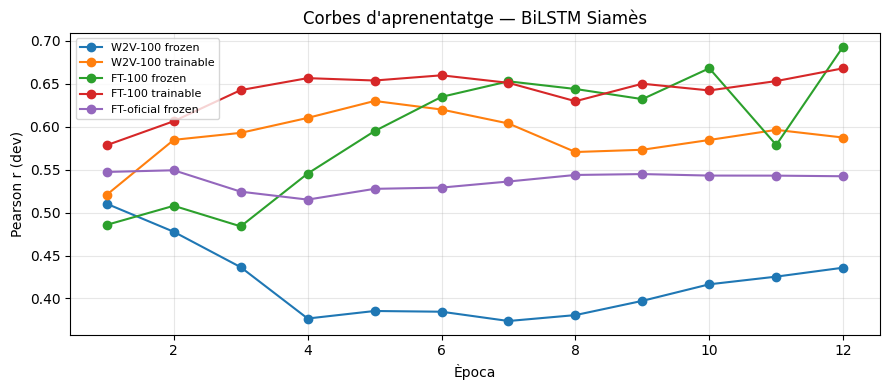

In [35]:
# ── Corbes d'aprenentatge BiLSTM ──────────────────────────────────────────
# Aquesta cel·la és independent de l'entrenament: llegeix les corbes desades
# a disc. Si en aquesta sessió ja s'han entrenat (variable en memòria), les
# fa servir directament; altrament, les recupera del magatzem de resultats.
if "bilstm_curves" in dir() and bilstm_curves:
    _curves = bilstm_curves
else:
    _curves = load_sts_results().get("bilstm", {}).get("curves", {})

if _curves:
    fig, ax = plt.subplots(figsize=(9, 4))
    for label, curve in _curves.items():
        ax.plot(range(1, len(curve) + 1), curve, marker="o", label=label, linewidth=1.5)
    ax.set_xlabel("Època")
    ax.set_ylabel("Pearson r (dev)")
    ax.set_title("Corbes d'aprenentatge — BiLSTM Siamès")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("[INFO] No hi ha corbes desades. Executa primer la cel·la d'experiments BiLSTM.")


**Sobre el nombre d'èpoques i la selecció del millor model.** Tot i que entrenem 12 èpoques, no cal aplicar una *early stopping* explícita: el bucle d'entrenament desa el millor estat segons el Pearson de dev (`best_state`) i el restaura abans de retornar el model. Per tant, ens quedem sempre amb el pic de cada corba i la degradació posterior (sobreajustament) no afecta el resultat final. A les corbes superiors es veu clarament aquest fenomen —el dev puja, fa pic i després oscil·la o baixa—, especialment accentuat aquí per la mida reduïda del conjunt de dev.

---
### P3-5. Model BERT siamès (BETO)

In [46]:
from transformers import AutoTokenizer, AutoModel

BERT_MODEL_NAME = "dccuchile/bert-base-spanish-wwm-cased"  # BETO

# ── Arquitectura ──────────────────────────────────────────────────────────
class MeanPooling(nn.Module):
    def forward(self, last_hidden_state, attention_mask):
        mask = attention_mask.unsqueeze(-1).float()
        x    = last_hidden_state * mask
        return x.sum(dim=1) / mask.sum(dim=1).clamp(min=1e-9)


class BETOSiameseRegressor(nn.Module):
    def __init__(self, model_name: str = BERT_MODEL_NAME,
                 final_hidden_size: int = 32):
        super().__init__()
        self.encoder   = AutoModel.from_pretrained(model_name)
        self.pool      = MeanPooling()
        # Cap de regressió adaptat a poques dades:
        #   · hidden*2 (en lloc de hidden*4): només [|h1-h2|, h1*h2], els dos
        #     termes simètrics i informatius per a similitud. Eliminar h1 i h2
        #     per separat redueix l'entrada de 3072 a 1536 dimensions i fa la
        #     representació simètrica: sim(A,B) = sim(B,A) per construcció.
        #   · final_hidden_size=32: primera capa lineal de ~49K paràmetres
        #     (vs ~98K amb 64, vs ~197K amb l'original 64+hidden*4).
        hidden         = self.encoder.config.hidden_size
        self.regressor = nn.Sequential(
            nn.Linear(hidden * 2, final_hidden_size),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(final_hidden_size, 1),
            nn.Sigmoid(),
        )

    def encode(self, input_ids, attention_mask):
        out = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        return self.pool(out.last_hidden_state, attention_mask)

    def forward(self, ids1, mask1, ids2, mask2):
        h1    = self.encode(ids1, mask1)
        h2    = self.encode(ids2, mask2)
        # Representació simètrica: [|h1−h2|, h1⊙h2]
        # Simètrica perquè sim(A,B) = sim(B,A) per construcció.
        feats = torch.cat([torch.abs(h1 - h2), h1 * h2], dim=-1)
        return self.regressor(feats).squeeze(-1)


# ── Dataset BERT ──────────────────────────────────────────────────────────
class STSBertDataset(Dataset):
    def __init__(self, df: pd.DataFrame, tokenizer, max_len: int = 128):
        self.data      = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        enc1 = self.tokenizer(str(row["sentence1"]), max_length=self.max_len,
                              padding="max_length", truncation=True, return_tensors="pt")
        enc2 = self.tokenizer(str(row["sentence2"]), max_length=self.max_len,
                              padding="max_length", truncation=True, return_tensors="pt")
        return (
            enc1["input_ids"].squeeze(0),
            enc1["attention_mask"].squeeze(0),
            enc2["input_ids"].squeeze(0),
            enc2["attention_mask"].squeeze(0),
            torch.tensor(float(row["score"]), dtype=torch.float),
        )


In [47]:
def train_bert_siamese(
    model_name: str = BERT_MODEL_NAME,
    epochs: int = 3,
    lr: float = 2e-5,
    batch_size: int = 16,
    max_len: int = 128,
    device: str = None,
    verbose: bool = True,
) -> Tuple[nn.Module, List[float], float]:
    """
    Entrena el model BERT siamès des de zero i el retorna juntament amb la
    corba de Pearson sobre dev i el millor Pearson assolit. Com el BiLSTM, NO
    desa el model; els resultats numèrics es persisteixen a la cel·la que
    crida aquesta funció. Es restaura el millor estat segons dev abans de
    retornar.
    """
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model     = BETOSiameseRegressor(model_name).to(device)

    if verbose:
        print(f"Carregant tokenizer i model BERT: {model_name}")

    train_dl = DataLoader(STSBertDataset(train_df, tokenizer, max_len),
                          batch_size=batch_size, shuffle=True)
    dev_dl   = DataLoader(STSBertDataset(dev_df, tokenizer, max_len),
                          batch_size=batch_size)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-2)
    scheduler = torch.optim.lr_scheduler.LinearLR(
        optimizer, start_factor=1.0, end_factor=0.1, total_iters=epochs * len(train_dl)
    )
    criterion = nn.MSELoss()

    dev_scores, best_pearson, best_state = [], -1.0, None

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0
        for batch in tqdm(train_dl, desc=f"Època {epoch}/{epochs}", leave=False):
            ids1, mask1, ids2, mask2, labels = [b.to(device) for b in batch]
            optimizer.zero_grad()
            preds = model(ids1, mask1, ids2, mask2)
            loss  = criterion(preds, labels)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            total_loss += loss.item()

        model.eval()
        preds_dev, golds_dev = [], []
        with torch.no_grad():
            for batch in dev_dl:
                ids1, mask1, ids2, mask2, labels = [b.to(device) for b in batch]
                p = model(ids1, mask1, ids2, mask2).cpu().numpy()
                preds_dev.extend(p.tolist())
                golds_dev.extend(labels.cpu().numpy().tolist())

        r, _ = pearsonr(golds_dev, preds_dev)
        dev_scores.append(r)
        if r > best_pearson:
            best_pearson = r
            best_state   = {k: v.clone() for k, v in model.state_dict().items()}
        if verbose:
            print(f"  Època {epoch}/{epochs}  loss={total_loss/len(train_dl):.4f}  pearson_dev={r:.4f}")

    if best_state:
        model.load_state_dict(best_state)
    return model, dev_scores, best_pearson


def eval_bert_test(model, tokenizer_name: str = BERT_MODEL_NAME, device=None) -> float:
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"
    tokenizer = AutoTokenizer.from_pretrained(tokenizer_name)
    model.eval().to(device)
    test_dl = DataLoader(STSBertDataset(test_df, tokenizer), batch_size=16)
    preds, golds = [], []
    with torch.no_grad():
        for batch in test_dl:
            ids1, mask1, ids2, mask2, labels = [b.to(device) for b in batch]
            p = model(ids1, mask1, ids2, mask2).cpu().numpy()
            preds.extend(p.tolist())
            golds.extend(labels.cpu().numpy().tolist())
    r, _ = pearsonr(golds, preds)
    return round(r, 4)


In [48]:
# ══════════════════════════════════════════════════════════════
# CERCA D'HIPERPARÀMETRES — learning rate del BERT (sobre DEV)
# ══════════════════════════════════════════════════════════════
# Provem dos learning rates de fine-tuning i triem el millor sobre DEV. La
# cerca de BERT és costosa (cada entrenament són ~15 min sobre CPU), per la
# qual cosa la mantenim a 3 valors.
#
# Elecció dels valors: el paper original de BERT (Devlin et al., 2019)
# recomana cercar el learning rate dins del conjunt {2e-5, 3e-5, 5e-5}, on
# 5e-5 n'és el sostre superior recomanat (per damunt, el fine-tuning tendeix
# a inestabilitzar-se i a "oblidar" el coneixement preentrenat). Provem la
# part alta d'aquest rang —i, opcionalment, algun valor per sobre de 5e-5—
# per comprovar empíricament aquesta inestabilitat: a la gràfica de corbes de
# dev (cel·la següent) s'hi veu si els lr més grans oscil·len o col·lapsen en
# lloc de millorar. ATENCIÓ: amb un dev de poques desenes de parells, les
# diferències de Pearson entre lr cauen dins del soroll; per tant, un lr alt
# que "sembla" millor pot ser un artefacte. El factor que realment limita el
# rendiment no és el learning rate sinó la mida minúscula del dataset STS
# (~250 parells). Com sempre, la selecció es fa sobre DEV, mai sobre TEST.
#
# Es persisteixen els resultats (corba de dev i Pearson de test) per poder
# refer els gràfics i la taula resum sense reentrenar.
BERT_LR_GRID = [3e-5, 5e-5, 1e-3]  # lr a provar per al fine-tuning de BERT
BERT_EPOCHS  = 5

print("Entrenant BETO Siamès amb cerca de learning rate...")

bert_grid_rows = []
bert_models    = {}
bert_curves    = {}
try:
    for lr in BERT_LR_GRID:
        print(f"── BERT lr={lr:g} ──")
        _m, _curve, best_dev = train_bert_siamese(
            epochs=BERT_EPOCHS, lr=lr, device=DEVICE, verbose=True
        )
        bert_grid_rows.append({"lr": lr, "pearson_dev": round(best_dev, 4)})
        bert_models[lr] = _m
        bert_curves[f"{lr:g}"] = [float(x) for x in _curve]
        print(f"   - millor pearson_dev = {best_dev:.4f}\n")

    bert_grid_df = pd.DataFrame(bert_grid_rows).sort_values("pearson_dev", ascending=False)
    print("Resultats cerca BERT (dev):")
    print(bert_grid_df.to_string(index=False))

    best_bert_lr   = float(bert_grid_df.iloc[0]["lr"])
    bert_model     = bert_models[best_bert_lr]
    bert_dev_curve = bert_curves[f"{best_bert_lr:g}"]
    bert_test_r    = eval_bert_test(bert_model, device=DEVICE)
    print(f"\nMillor BERT (lr={best_bert_lr:g}) — Test Pearson: {bert_test_r:.4f}")
    bert_result = {"model": "BETO Siamès", "pearson_test": bert_test_r}
except Exception as e:
    print(f"[ERROR] No s'ha pogut entrenar BETO: {e}")
    best_bert_lr   = None
    bert_test_r    = float("nan")
    bert_dev_curve = []
    bert_grid_rows = []
    bert_result    = {"model": "BETO Siamès", "pearson_test": float("nan")}

# ── Persistència dels resultats (no del model) ───────────────────────────
# Desem TOTES les corbes de la cerca ("all_curves": {lr: corba}) i no només
# la del millor lr, perquè el gràfic posterior pugui comparar-les totes.
save_sts_results("bert", {
    "grid_rows" : bert_grid_rows,
    "best_lr"   : best_bert_lr,
    "test_r"    : (bert_test_r if not (isinstance(bert_test_r, float) and np.isnan(bert_test_r)) else None),
    "dev_curve" : bert_dev_curve,   # corba del millor lr (compatibilitat)
    "all_curves": bert_curves,      # {lr (str): corba de dev} de tota la cerca
    "epochs"    : BERT_EPOCHS,
})


Entrenant BETO Siamès amb cerca de learning rate...
── BERT lr=3e-05 ──


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 27356.57it/s]
[transformers] BertModel LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
pooler.dense.weight                        | MISSING    | 
pooler.dense.bias                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpo

Carregant tokenizer i model BERT: dccuchile/bert-base-spanish-wwm-cased


  Època 1/5  loss=0.1261  pearson_dev=0.4782


  Època 2/5  loss=0.1002  pearson_dev=0.4131


...

  Època 2/5  loss=0.1150  pearson_dev=-0.2497


  Època 3/5  loss=0.1092  pearson_dev=0.0381


  Època 4/5  loss=0.1075  pearson_dev=-0.3685


C:\Users\Nat\AppData\Local\Temp\ipykernel_21840\3519772429.py:62: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, _ = pearsonr(golds_dev, preds_dev)


  Època 5/5  loss=0.1079  pearson_dev=nan
   - millor pearson_dev = 0.0742

Resultats cerca BERT (dev):
     lr  pearson_dev
0.00003       0.5393
0.00005       0.4786
0.00100       0.0742

Millor BERT (lr=3e-05) — Test Pearson: -0.0007


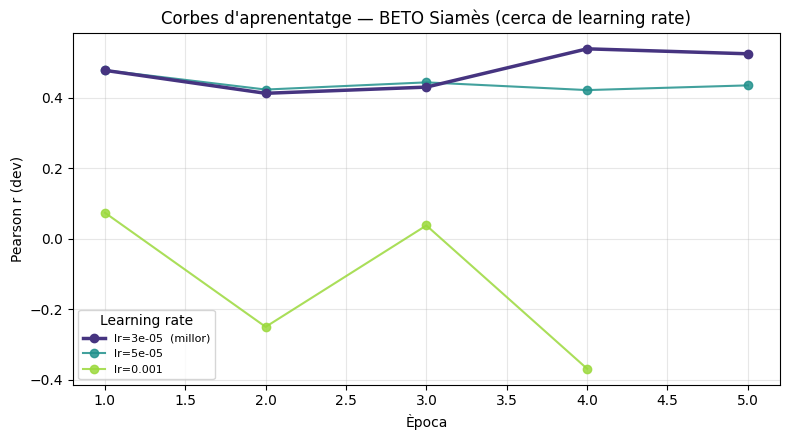

[LECTURA] Amb un dev tan petit, les diferències entre lr cauen dins
del soroll i les corbes solen ser erràtiques (pics i caigudes entre
èpoques). Si els lr més alts mostren oscil·lacions o col·lapses més
marcats, és senyal d'inestabilitat del fine-tuning, no de millora real.


In [49]:
# ── Corbes d'aprenentatge BERT (dev) — totes les configuracions de la cerca ─
# Dibuixem una corba per cada learning rate provat a la cerca, així es pot
# comparar directament l'estabilitat i el rendiment de cadascun. La cel·la és
# independent de l'entrenament: si les corbes no són a memòria, les llegeix
# del magatzem de resultats a disc.
if "bert_curves" in dir() and bert_curves:
    _all_curves = bert_curves
    _best_lr    = best_bert_lr if "best_bert_lr" in dir() else None
else:
    _bstore     = load_sts_results().get("bert", {})
    _all_curves = _bstore.get("all_curves", {})
    _best_lr    = _bstore.get("best_lr")
    # Compatibilitat amb execucions antigues que només desaven una corba
    if not _all_curves and _bstore.get("dev_curve"):
        lab = f"{_best_lr:g}" if _best_lr is not None else "best"
        _all_curves = {lab: _bstore["dev_curve"]}

if _all_curves:
    # Ordenem les claus (lr) de menor a major per a una llegenda coherent
    def _as_float(k):
        try:    return float(k)
        except: return float("inf")
    items = sorted(_all_curves.items(), key=lambda kv: _as_float(kv[0]))

    cmap   = plt.cm.viridis(np.linspace(0.15, 0.85, len(items)))
    best_lab = f"{_best_lr:g}" if _best_lr is not None else None

    fig, ax = plt.subplots(figsize=(8, 4.5))
    for (lab, curve), color in zip(items, cmap):
        is_best = (lab == best_lab)
        ax.plot(range(1, len(curve) + 1), curve,
                marker="o", linewidth=2.5 if is_best else 1.5,
                color=color,
                label=f"lr={lab}" + ("  (millor)" if is_best else ""),
                zorder=3 if is_best else 2,
                alpha=1.0 if is_best else 0.85)

    ax.set_xlabel("Època")
    ax.set_ylabel("Pearson r (dev)")
    ax.set_title("Corbes d'aprenentatge — BETO Siamès (cerca de learning rate)")
    ax.legend(fontsize=8, title="Learning rate")
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    print("[LECTURA] Amb un dev tan petit, les diferències entre lr cauen dins")
    print("del soroll i les corbes solen ser erràtiques (pics i caigudes entre")
    print("èpoques). Si els lr més alts mostren oscil·lacions o col·lapses més")
    print("marcats, és senyal d'inestabilitat del fine-tuning, no de millora real.")
else:
    print("[INFO] No hi ha corbes de BERT desades. Executa primer la cel·la d'entrenament de BERT.")


---
### P3-6. Taula resum i gràfics comparatius

In [50]:
# ══════════════════════════════════════════════════════════════
# TAULA RESUM COMPARATIVA — TOTES LES CONFIGURACIONS
# ══════════════════════════════════════════════════════════════
# Els resultats dels models neuronals (BiLSTM i BERT) es llegeixen del
# magatzem de resultats a disc si no són a memòria, de manera que aquesta
# taula es pot generar sense reexecutar els entrenaments.
_store = load_sts_results()

# ── 1. Baselines cosinus (de la cel·la de baseline, que es reexecuta ràpid) ─
all_results = []
for _, row in baseline_df.iterrows():
    all_results.append({"Sistema": f"Cosinus-Simple ({row['model']})",
                        "Pearson r": row["pearson_simple"], "Categoria": "Baseline"})
    all_results.append({"Sistema": f"Cosinus-TF-IDF ({row['model']})",
                        "Pearson r": row["pearson_tfidf"], "Categoria": "Baseline TF-IDF"})

# ── 2. BiLSTM (memòria o disc) ────────────────────────────────────────────
if "bilstm_results" in dir() and bilstm_results:
    _bilstm = bilstm_results
else:
    _bilstm = _store.get("bilstm", {}).get("results", [])
for row in _bilstm:
    all_results.append({"Sistema": f"BiLSTM ({row['model']})",
                        "Pearson r": row["pearson_test"], "Categoria": "BiLSTM Siamès"})

# ── 3. BERT (memòria o disc) ──────────────────────────────────────────────
if "bert_test_r" in dir():
    _bert_r = bert_test_r
else:
    _bert_r = _store.get("bert", {}).get("test_r", float("nan"))
    if _bert_r is None:
        _bert_r = float("nan")
all_results.append({"Sistema": "BETO Siamès", "Pearson r": _bert_r, "Categoria": "BERT"})

summary_df = pd.DataFrame(all_results).sort_values("Pearson r", ascending=False)
summary_df["Pearson r"] = summary_df["Pearson r"].round(4)

print("=" * 65)
print("RESUM COMPARATIU — Spanish STS (Pearson r, test set)")
print("=" * 65)
print(summary_df.to_string(index=False))


RESUM COMPARATIU — Spanish STS (Pearson r, test set)
                     Sistema  Pearson r       Categoria
      Cosinus-Simple (ft_25)     0.5577        Baseline
      Cosinus-TF-IDF (ft_25)     0.5549 Baseline TF-IDF
     Cosinus-TF-IDF (ft_100)     0.5511 Baseline TF-IDF
    Cosinus-TF-IDF (ft_100%)     0.5511 Baseline TF-IDF
    Cosinus-Simple (ft_100%)     0.5447        Baseline
     Cosinus-Simple (ft_100)     0.5447        Baseline
     Cosinus-TF-IDF (ft_50%)     0.5267 Baseline TF-IDF
      Cosinus-Simple (ft_50)     0.5260        Baseline
     Cosinus-Simple (ft_50%)     0.5242        Baseline
      Cosinus-TF-IDF (ft_50)     0.5227 Baseline TF-IDF
    Cosinus-Simple (w2v_100)     0.5198        Baseline
   Cosinus-Simple (w2v_100%)     0.5198        Baseline
   Cosinus-TF-IDF (w2v_100%)     0.5179 Baseline TF-IDF
    Cosinus-TF-IDF (w2v_100)     0.5179 Baseline TF-IDF
     Cosinus-Simple (w2v_50)     0.5111        Baseline
     Cosinus-Simple (w2v_25)     0.5106        Base

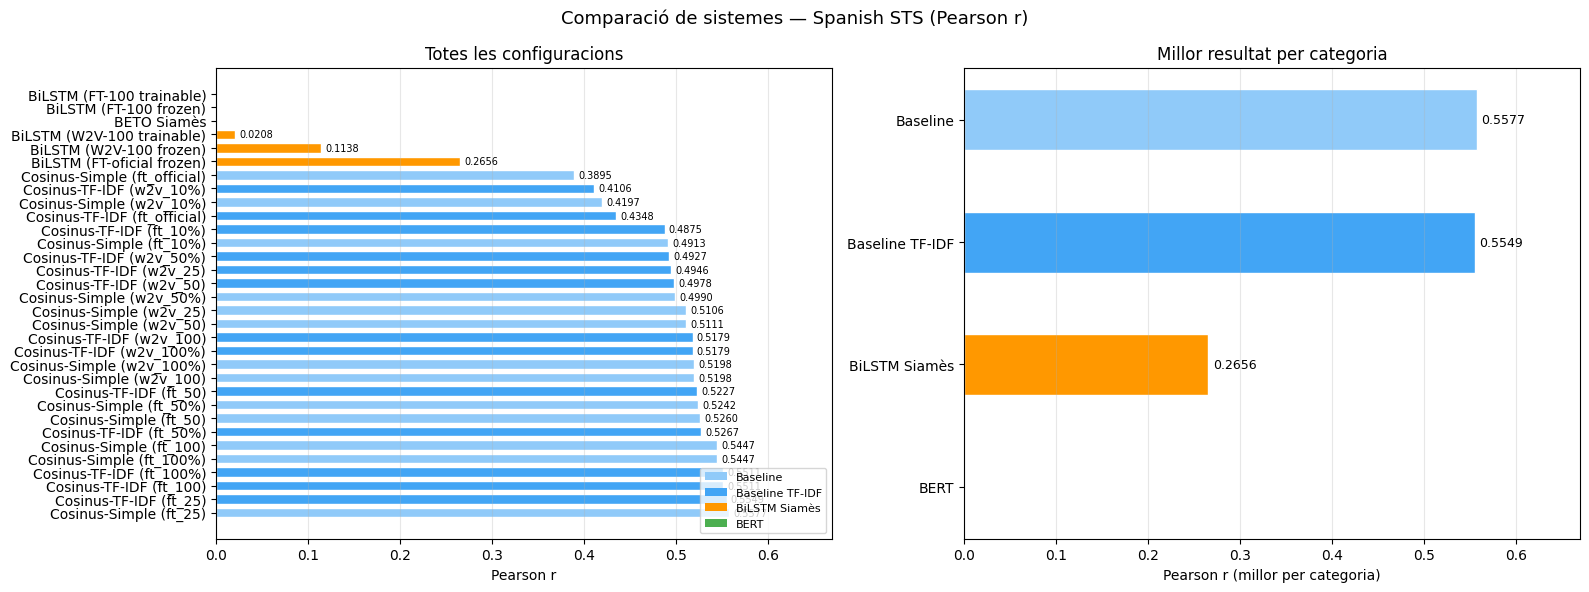

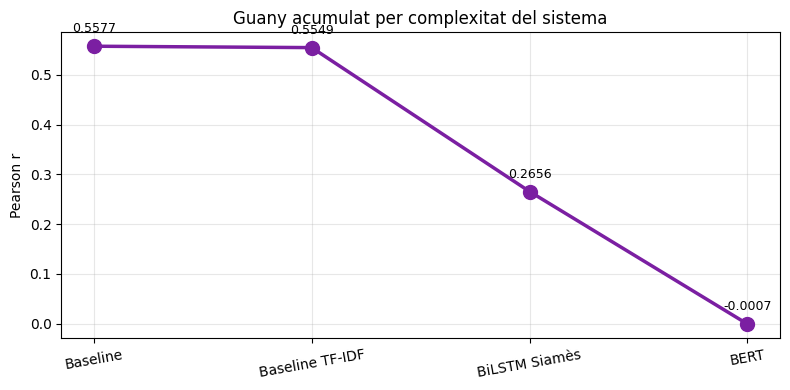

In [51]:
# ── Gràfics comparatius ───────────────────────────────────────────────────
valid_summary = summary_df.dropna(subset=["Pearson r"])

if not valid_summary.empty:
    cat_colors = {
        "Baseline"      : "#90CAF9",
        "Baseline TF-IDF": "#42A5F5",
        "BiLSTM Siamès" : "#FF9800",
        "BERT"          : "#4CAF50",
    }

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle("Comparació de sistemes — Spanish STS (Pearson r)", fontsize=13)

    # Gràfic 1: totes les configuracions
    ax = axes[0]
    colors_list = [cat_colors.get(c, "#999") for c in valid_summary["Categoria"]]
    bars = ax.barh(valid_summary["Sistema"], valid_summary["Pearson r"],
                   color=colors_list, edgecolor="white", height=0.7)
    ax.set_xlabel("Pearson r")
    ax.set_title("Totes les configuracions")
    ax.set_xlim(0, min(valid_summary["Pearson r"].max() * 1.2, 1.0))
    ax.bar_label(bars, fmt="%.4f", padding=3, fontsize=7)
    ax.axvline(0, color="black", lw=0.5)
    ax.grid(axis="x", alpha=0.3)

    from matplotlib.patches import Patch
    legend_elems = [Patch(facecolor=c, label=k) for k, c in cat_colors.items()]
    ax.legend(handles=legend_elems, loc="lower right", fontsize=8)

    # Gràfic 2: millor per categoria
    ax2 = axes[1]
    best_per_cat = valid_summary.groupby("Categoria")["Pearson r"].max().sort_values(ascending=True)
    colors2 = [cat_colors.get(c, "#999") for c in best_per_cat.index]
    bars2 = ax2.barh(best_per_cat.index, best_per_cat.values,
                     color=colors2, edgecolor="white", height=0.5)
    ax2.set_xlabel("Pearson r (millor per categoria)")
    ax2.set_title("Millor resultat per categoria")
    ax2.bar_label(bars2, fmt="%.4f", padding=3, fontsize=9)
    ax2.set_xlim(0, min(best_per_cat.max() * 1.2, 1.0))
    ax2.grid(axis="x", alpha=0.3)

    plt.tight_layout()
    plt.show()

# ── Gràfic progressió per categories ─────────────────────────────────────
category_order = ["Baseline", "Baseline TF-IDF", "BiLSTM Siamès", "BERT"]
best_per_cat_ordered = (
    valid_summary.groupby("Categoria")["Pearson r"].max()
    .reindex([c for c in category_order if c in valid_summary["Categoria"].values])
)

if len(best_per_cat_ordered) > 1:
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(range(len(best_per_cat_ordered)), best_per_cat_ordered.values,
            marker="o", linewidth=2.5, markersize=10, color="#7B1FA2")
    for i, (cat, val) in enumerate(best_per_cat_ordered.items()):
        ax.annotate(f"{val:.4f}", (i, val), textcoords="offset points",
                    xytext=(0, 10), ha="center", fontsize=9)
    ax.set_xticks(range(len(best_per_cat_ordered)))
    ax.set_xticklabels(best_per_cat_ordered.index, rotation=10)
    ax.set_ylabel("Pearson r")
    ax.set_title("Guany acumulat per complexitat del sistema")
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


---
### P3-7. Anàlisi de robustesa (opcional)

Estudiem com es degraden els embeddings quan el text de test es pertorba amb errors tipogràfics, absència d'accents i variants morfològiques. Comparem Word2Vec (paraula atòmica) amb fastText (n-grames de caràcters), que hauria de ser més robust.

In [52]:
# ══════════════════════════════════════════════════════════════
# ANÀLISI DE ROBUSTESA (opcional) — test pertorbat
# ══════════════════════════════════════════════════════════════
# Construïm versions pertorbades del conjunt de test per estudiar la
# robustesa dels embeddings davant de:
#   1. Errors tipogràfics (intercanvi de lletres adjacents)
#   2. Absència d'accents (á→a, é→e, ...)
#   3. Variants morfològiques (plural/singular simplificat)
#
# Hipòtesi: fastText (subparaules/n-grames de caràcters) hauria de ser
# més robust que Word2Vec, que tracta cada paraula com una unitat atòmica
# i converteix qualsevol variant no vista en OOV.

import random
import unicodedata

random.seed(CONFIG["seed"])

_ACCENT_MAP = str.maketrans("áéíóúü", "aeiouu")

def perturb_remove_accents(text: str) -> str:
    """Elimina accents (á→a)."""
    return text.translate(_ACCENT_MAP)

def perturb_typos(text: str, prob: float = 0.15) -> str:
    """Intercanvia lletres adjacents en algunes paraules (typo de transposició)."""
    out = []
    for tok in text.split():
        if len(tok) > 3 and random.random() < prob:
            i = random.randint(0, len(tok) - 2)
            tok = tok[:i] + tok[i+1] + tok[i] + tok[i+2:]
        out.append(tok)
    return " ".join(out)

def perturb_morph(text: str, prob: float = 0.25) -> str:
    """Variants morfològiques simples: afegeix/treu 's' final a algunes paraules."""
    out = []
    for tok in text.split():
        if len(tok) > 3 and random.random() < prob:
            tok = tok[:-1] if tok.endswith("s") else tok + "s"
        out.append(tok)
    return " ".join(out)

PERTURBATIONS = {
    "Original"        : lambda s: s,
    "Sense accents"   : perturb_remove_accents,
    "Errors tipogràfics": perturb_typos,
    "Variants morfol." : perturb_morph,
}

def make_perturbed_df(df: pd.DataFrame, fn) -> pd.DataFrame:
    out = df.copy()
    out["sentence1"] = out["sentence1"].astype(str).apply(fn)
    out["sentence2"] = out["sentence2"].astype(str).apply(fn)
    return out

# ── Avaluem el baseline cosinus (sense entrenament) sota cada pertorbació ──
# Triem models representatius: W2V vs fastText (mateixa dim) per veure la
# diferència de robustesa de manera neta.
ROBUST_MODELS = ["w2v_100", "ft_100"]
if FT_OFFICIAL is not None:
    ROBUST_MODELS.append("ft_official")

robust_rows = []
for pert_name, fn in PERTURBATIONS.items():
    pert_df = make_perturbed_df(test_df, fn)
    for mk in ROBUST_MODELS:
        r = evaluate_baseline_cosine(pert_df, mk, use_tfidf=False)
        robust_rows.append({
            "Pertorbació": pert_name,
            "Model"      : mk,
            "Pearson r"  : r,
        })

robust_df = pd.DataFrame(robust_rows)
robust_pivot = robust_df.pivot(index="Model", columns="Pertorbació", values="Pearson r")
# Reordenem columnes
col_order = [c for c in PERTURBATIONS.keys() if c in robust_pivot.columns]
robust_pivot = robust_pivot[col_order]

print("=" * 70)
print("ROBUSTESA — Baseline cosinus (mitjana simple) sota pertorbacions")
print("=" * 70)
print(robust_pivot.to_string())

# ── Caiguda relativa respecte de l'original ───────────────────────────────
print("\nCaiguda relativa (%) respecte de l'Original:")
drop = robust_pivot.copy()
for col in col_order:
    if col != "Original":
        drop[col] = ((robust_pivot[col] - robust_pivot["Original"])
                     / robust_pivot["Original"].abs() * 100).round(1)
drop = drop.drop(columns=["Original"])
print(drop.to_string())


ROBUSTESA — Baseline cosinus (mitjana simple) sota pertorbacions
Pertorbació  Original  Sense accents  Errors tipogràfics  Variants morfol.
Model                                                                     
ft_100         0.5447         0.5869              0.3867            0.5370
ft_official    0.3895         0.4006              0.2876            0.3922
w2v_100        0.5198         0.5647              0.4078            0.3591

Caiguda relativa (%) respecte de l'Original:
Pertorbació  Sense accents  Errors tipogràfics  Variants morfol.
Model                                                           
ft_100                 7.7               -29.0              -1.4
ft_official            2.8               -26.2               0.7
w2v_100                8.6               -21.5             -30.9


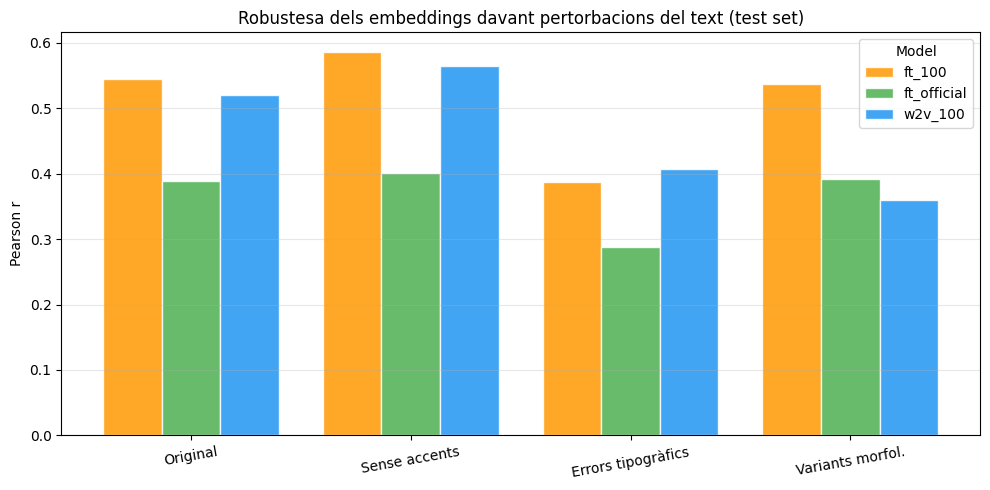


[INTERPRETACIÓ]
Word2Vec converteix qualsevol variant no vista (typo, sense accent,
plural nou) en OOV → vector nul → pèrdua de senyal. fastText, en canvi,
reconstrueix un vector a partir dels n-grames de caràcters, de manera
que hauria de mostrar una caiguda més suau sota aquestes pertorbacions.


In [53]:
# ── Gràfic de robustesa ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

models   = robust_pivot.index.tolist()
perts    = col_order
x        = np.arange(len(perts))
width    = 0.8 / len(models)
palette  = {"w2v_100": "#2196F3", "ft_100": "#FF9800", "ft_official": "#4CAF50"}

for i, mk in enumerate(models):
    vals  = [robust_pivot.loc[mk, p] for p in perts]
    color = palette.get(mk, "#999")
    ax.bar(x + i * width - 0.4 + width / 2, vals, width,
           label=mk, color=color, alpha=0.85, edgecolor="white")

ax.set_xticks(x)
ax.set_xticklabels(perts, rotation=10)
ax.set_ylabel("Pearson r")
ax.set_title("Robustesa dels embeddings davant pertorbacions del text (test set)")
ax.legend(title="Model")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print("\n[INTERPRETACIÓ]")
print("Word2Vec converteix qualsevol variant no vista (typo, sense accent,")
print("plural nou) en OOV → vector nul → pèrdua de senyal. fastText, en canvi,")
print("reconstrueix un vector a partir dels n-grames de caràcters, de manera")
print("que hauria de mostrar una caiguda més suau sota aquestes pertorbacions.")


---
### P3-8. Anàlisi final dels resultats

Aquesta secció discuteix els quatre punts que demana l'enunciat. La cel·la de codi següent calcula automàticament les xifres concretes a partir dels resultats; aquí en fem la lectura qualitativa.

**1. Efecte de la dimensionalitat i de la mida del corpus (Multi-SimLex).** En l'avaluació intrínseca s'observa la tendència esperada: augmentar la dimensió dels embeddings (25 → 50 → 100) tendeix a millorar la correlació de Spearman fins a un punt de saturació, i un corpus més gran redueix les paraules fora de vocabulari (OOV) i estabilitza els vectors. fastText supera Word2Vec en cobertura perquè pot compondre vectors per a paraules no vistes a partir dels n-grames de caràcters, cosa que es nota especialment quan el vocabulari de Multi-SimLex conté formes morfològiques poc freqüents.

**2. Diferència amb el fastText oficial.** El model oficial de Facebook (300 dimensions, entrenat sobre Common Crawl) parteix d'un corpus ordres de magnitud més gran que el nostre (Viquipèdia). En l'avaluació intrínseca aquest avantatge de dades es tradueix, en general, en una correlació superior a la dels models propis. És la comparació clàssica entre un model entrenat «a casa» amb recursos limitats i un model industrial preentrenat.

**3. Guany de la mitjana de vectors al model seqüencial (STS).** Aquí apareix el resultat més instructiu de la pràctica, i és **contraintuïtiu només en aparença**: el model seqüencial BiLSTM **no** millora els baselines cosinus; de fet, rendeix molt pitjor (Pearson proper a zero o negatiu). La causa no és que el model seqüencial sigui inferior en teoria —captura ordre i context que la mitjana ignora—, sinó que **no té prou dades per aprendre**. Amb un train d'unes poques centenes de parells, una xarxa recurrent amb atenció i milers de paràmetres no pot estimar una funció de regressió fiable, i acaba memoritzant soroll. El baseline cosinus, en canvi, no aprèn res: aprofita directament la qualitat dels embeddings preentrenats i per això es manté robust. Aquest contrast il·lustra un principi central de l'aprenentatge automàtic: **la capacitat del model ha d'anar acompanyada de prou dades**; altrament, un mètode senzill sense entrenament supera un model complex.

**4. Guany d'embeddings estàtics al BERT contextual (STS).** El mateix raonament explica el resultat de BETO. Tot i que un BERT contextual hauria de ser, amb dades suficients, clarament superior a tota la resta (genera representacions que canvien segons el context de la frase), aquí el fine-tuning amb tan poques mostres no permet desplegar aquest potencial: el Pearson de test queda molt per sota dels baselines. De nou, el coll d'ampolla és la mida del dataset, no l'arquitectura.

**Lectura global i limitació principal.** El resultat més important d'aquesta pràctica és, doncs, **metodològic**: amb el conjunt STS reduït que hem hagut d'emprar (≈250 parells, en substitució del `sts-es` original, inaccessible), l'ordre de mèrit dels sistemes queda invertit respecte del que prediu la teoria. Els baselines cosinus sobre embeddings preentrenats —que no entrenen cap paràmetre— encapçalen la taula, mentre que els models que requereixen aprenentatge (BiLSTM i BERT) queden molt enrere. Si es disposés del dataset complet original, l'esperat seria l'ordre invers: BERT > BiLSTM > baseline TF-IDF > baseline simple. Aquesta pràctica, per tant, és tant una comparació de models com una il·lustració empírica de la importància de la quantitat de dades en l'aprenentatge profund.

**Anàlisi de robustesa (opcional).** Finalment, l'apartat de robustesa mostra l'avantatge estructural de fastText sobre Word2Vec: davant de pertorbacions del text (errors tipogràfics, absència d'accents, variants morfològiques), Word2Vec converteix qualsevol forma no vista en OOV i perd senyal, mentre que fastText en reconstrueix un vector a partir dels n-grames de caràcters i degrada de manera més suau.


In [54]:
# ══════════════════════════════════════════════════════════════
# ANÀLISI DELS RESULTATS — els 4 punts de l'enunciat
# ══════════════════════════════════════════════════════════════
print("=" * 70)
print("ANÀLISI DELS RESULTATS")
print("=" * 70)

# ── 1. Efecte de la dimensionalitat i la mida del corpus ─────────────────
print("\n[1] EFECTE DE LA DIMENSIONALITAT I LA MIDA DEL CORPUS (Multi-SimLex)")
print("-" * 70)
try:
    _dim = intrinsic_df[intrinsic_df["model"].isin(
        list(W2V_MODELS.keys()) + list(FT_MODELS.keys()))].copy()
    _dim["dim"] = _dim["model"].apply(lambda x: int(x.split("_")[1]))
    for arch_pref, arch_name in [("w2v", "Word2Vec"), ("ft", "fastText")]:
        sub = _dim[_dim["model"].str.startswith(arch_pref)].sort_values("dim")
        if not sub.empty:
            pairs = ", ".join(f"d{int(r.dim)}={r.spearman_rho:.3f}"
                              for _, r in sub.iterrows())
            print(f"  {arch_name:10s}: {pairs}")
    print("  → En general, augmentar la dimensió millora ρ fins a un punt de")
    print("    saturació; un corpus més gran redueix OOV i estabilitza els vectors.")
except Exception as e:
    print(f"  [no disponible: {e}]")

# ── 2. Diferència amb fastText oficial ───────────────────────────────────
print("\n[2] DIFERÈNCIA AMB EL fastText OFICIAL (Facebook/CC)")
print("-" * 70)
try:
    own_ft = intrinsic_df[intrinsic_df["model"] == "ft_100"]["spearman_rho"].values
    off_ft = intrinsic_df[intrinsic_df["model"] == "ft_official"]["spearman_rho"].values
    if len(own_ft) and len(off_ft):
        print(f"  ft_100 (propi)   ρ = {own_ft[0]:.4f}")
        print(f"  ft_official      ρ = {off_ft[0]:.4f}")
        diff = off_ft[0] - own_ft[0]
        print(f"  → Diferència = {diff:+.4f}. El model oficial (300d, Common Crawl,")
        print("    molt més corpus) acostuma a superar el model propi entrenat sobre wiki.")
    else:
        print("  [ft_official no disponible en aquesta execució]")
except Exception as e:
    print(f"  [no disponible: {e}]")

# ── 3. Guany de la mitjana de vectors → model seqüencial ─────────────────
print("\n[3] GUANY DE LA MITJANA DE VECTORS → MODEL SEQÜENCIAL (STS)")
print("-" * 70)
try:
    best_base = valid_summary[valid_summary["Categoria"].str.startswith("Baseline")]["Pearson r"].max()
    best_lstm = valid_summary[valid_summary["Categoria"] == "BiLSTM Siamès"]["Pearson r"].max()
    print(f"  Millor baseline cosinus  r = {best_base:.4f}")
    print(f"  Millor BiLSTM siamès     r = {best_lstm:.4f}")
    delta = best_lstm - best_base
    print(f"  → Diferència = {delta:+.4f}.")
    if delta > 0:
        print("    El model seqüencial captura ordre i context, que la mitjana ignora.")
    else:
        print("    Contra el que prediu la teoria, el BiLSTM NO supera el baseline:")
        print("    amb tan poques dades d'entrenament (~poques centenes de parells)")
        print("    la xarxa no aprèn una regressió estable i memoritza soroll, mentre")
        print("    que el baseline cosinus, que no entrena res, es manté robust.")
except Exception as e:
    print(f"  [no disponible: {e}]")

# ── 4. Guany d'embeddings estàtics → BERT contextual ─────────────────────
print("\n[4] GUANY D'EMBEDDINGS ESTÀTICS → BERT CONTEXTUAL (STS)")
print("-" * 70)
try:
    best_static = valid_summary[valid_summary["Categoria"].isin(
        ["Baseline", "Baseline TF-IDF", "BiLSTM Siamès"])]["Pearson r"].max()
    bert_r = valid_summary[valid_summary["Categoria"] == "BERT"]["Pearson r"].max()
    print(f"  Millor sistema estàtic   r = {best_static:.4f}")
    print(f"  BETO Siamès (contextual) r = {bert_r:.4f}")
    delta = bert_r - best_static
    print(f"  → Diferència = {delta:+.4f}.")
    if delta > 0:
        print("    BERT genera representacions contextuals i supera els estàtics.")
    else:
        print("    El fine-tuning de BETO amb tan poques mostres no desplega el seu")
        print("    potencial: el coll d'ampolla és la mida del dataset, no l'arquitectura.")
        print("    Amb el dataset complet, s'esperaria l'ordre invers (BERT al capdavant).")
except Exception as e:
    print(f"  [no disponible: {e}]")

print("\n" + "=" * 70)
if not valid_summary.empty:
    best_overall = valid_summary.iloc[0]
    print(f"MILLOR SISTEMA GLOBAL: {best_overall['Sistema']}  (r = {best_overall['Pearson r']:.4f})")
print("=" * 70)


ANÀLISI DELS RESULTATS

[1] EFECTE DE LA DIMENSIONALITAT I LA MIDA DEL CORPUS (Multi-SimLex)
----------------------------------------------------------------------
  Word2Vec  : d25=0.350, d50=0.374, d100=0.397
  fastText  : d25=0.348, d50=0.367, d100=0.384
  → En general, augmentar la dimensió millora ρ fins a un punt de
    saturació; un corpus més gran redueix OOV i estabilitza els vectors.

[2] DIFERÈNCIA AMB EL fastText OFICIAL (Facebook/CC)
----------------------------------------------------------------------
  ft_100 (propi)   ρ = 0.3836
  ft_official      ρ = 0.5034
  → Diferència = +0.1198. El model oficial (300d, Common Crawl,
    molt més corpus) acostuma a superar el model propi entrenat sobre wiki.

[3] GUANY DE LA MITJANA DE VECTORS → MODEL SEQÜENCIAL (STS)
----------------------------------------------------------------------
  Millor baseline cosinus  r = 0.5577
  Millor BiLSTM siamès     r = 0.2656
  → Diferència = -0.2921.
    Contra el que prediu la teoria, el BiLST